In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
def J(i,j,p,nu):
    if i==j:
        return 1
    else:
        p_i=p[i]
        p_j= p[j]
        cos_theta = np.clip(np.dot(p_i, p_j), -1, 1)
        theta_ij = np.arccos(cos_theta) 
        x = np.pi*(np.abs(theta_ij)/np.pi)**nu
        return np.cos(x)
    
def r_10(i,n,p,k,T,N,nu,r0,eta,eps):
    N_i = n[i]*N
    sum = 0
    for j in range(k):
        sum+= J(i,j,p,nu)*n[j]
    deltaE = 2*k*sum - (eta - eps[i])
    return N_i*r0 / (1+np.exp(deltaE/T))

def r_01(i,n,p,k,T,N,nu,r0,eta,eps):
    N_i = (N/k) - n[i]*N
    sum = 0
    for j in range(k):
        sum+= J(i,j,p,nu)*n[j]
    deltaE = -2*k*sum + (eta - eps[i])
    return N_i*r0 / (1+np.exp(deltaE/T))

def R_tot(n,p,k,T,N,nu,r0,eta,eps):
    sum = 0
    for i in range(k):
        sum+= r_10(i,n,p,k,T,N,nu,r0,eta,eps) + r_01(i,n,p,k,T,N,nu,r0,eta,eps)
    return sum


def dt(n,p,k,T,N,nu,r0,eta,eps):
    R_tot_ = R_tot(n,p,k,T,N,nu,r0,eta,eps)
    r = np.random.uniform()
    return (1/R_tot_)*np.log(1/r)

def V(n,p,k,v0):
    sum=0
    for i in range(k):
        sum+= n[i]*p[i]
    return sum* v0

In [30]:
N = 60
k=3
eta = 0

#N0_0 = np.random.randint(0,N//3)
#N0_1 = N//3 - N0_0
#N1_0 = np.random.randint(0,N//3)
#N1_1 = N//3 - N1_0
#N2_0 = np.random.randint(0,N//3)
#N2_1 = N -N0_0 - N0_1 - N1_0 - N1_1 - N2_0


N0_0 = 0
N0_1 = N//3 
N1_0 = 0
N1_1 = N//3 
N2_0 = 0
N2_1 = N -N0_0 - N0_1 - N1_0 - N1_1 - N2_0



n0=N0_1/N
n1=N1_1/N
n2 = N2_1/N
n = np.array([n0,n1,n2])
x=[0.269,1.868]
xs=[x.copy()]


P0 = np.array([1.093,-1.196]) -x
P1 = np.array([-0.605,-1.289]) -x
P2 = np.array([0.267, -1.267]) -x
p = np.array([P0/np.linalg.norm(P0),P1/np.linalg.norm(P1),P2/np.linalg.norm(P2)])

eps=[0.15,0.15,0.03]

nu = 0.35
sigma_e = 0.2
v0= 3.5
r0= 40

T=0.45


t = 0
step_interval = 0.05
steps=0

while np.linalg.norm(P0) > 0.05 and np.linalg.norm(P1) > 0.05 and np.linalg.norm(P2) > 0.05:
    dt_ = dt(n,p,k,T,N,nu,r0,eta,eps)
    next_spatial_update = (steps+1)*step_interval
    
    if t+dt_>= next_spatial_update:
        t= next_spatial_update

        Vel = V(n,p,k,v0)
        x[0]+= Vel[0]*step_interval
        x[1]+= Vel[1]*step_interval
        P0-= Vel*step_interval
        P1 -= Vel*step_interval
        P2 -= Vel*step_interval
        
        # compute unit vectors
        p0 = P0 / np.linalg.norm(P0)
        p1 = P1 / np.linalg.norm(P1)
        p2 = P2 / np.linalg.norm(P2)
        for p_vec in [p0, p1,p2]:
            angle = np.random.normal(0, sigma_e)
            cos_a, sin_a = np.cos(angle), np.sin(angle)
            p_vec[:] = np.array([cos_a*p_vec[0] - sin_a*p_vec[1],
                                sin_a*p_vec[0] + cos_a*p_vec[1]])
        
        p = np.array([p0, p1,p2])
        xs.append(x.copy())

      
        steps+=1
        continue

    t += dt_
    alpha = np.random.uniform()

    p1_thres = r_10(0,n,p,k,T,N,nu,r0,eta,eps)/R_tot(n,p,k,T,N,nu,r0,eta,eps)
    p2_thres = p1_thres + r_01(0,n,p,k,T,N,nu,r0,eta,eps)/R_tot(n,p,k,T,N,nu,r0,eta,eps)
    p3_thres = p2_thres + r_10(1,n,p,k,T,N,nu,r0,eta,eps)/R_tot(n,p,k,T,N,nu,r0,eta,eps)
    p4_thres = p3_thres + r_01(1,n,p,k,T,N,nu,r0,eta,eps)/R_tot(n,p,k,T,N,nu,r0,eta,eps)
    p5_thres = p4_thres + r_10(2,n,p,k,T,N,nu,r0,eta,eps)/R_tot(n,p,k,T,N,nu,r0,eta,eps)

    if alpha <= p1_thres:
        N0_0 +=1
        N0_1 -=1
    elif alpha <= p2_thres:
        N0_0 -=1
        N0_1 +=1
    elif alpha <= p3_thres:
        N1_1-=1
        N1_0+=1
    elif alpha <= p4_thres:
        N1_1+=1
        N1_0-=1
    elif alpha <= p5_thres:
        N2_1 -=1
        N2_0 +=1
    else:
        N2_1 +=1
        N2_0 -=1

    n0=N0_1/N
    n1=N1_1/N
    n2 = N2_1/N
    n = np.array([n0,n1,n2])

    if t > 5:
        break


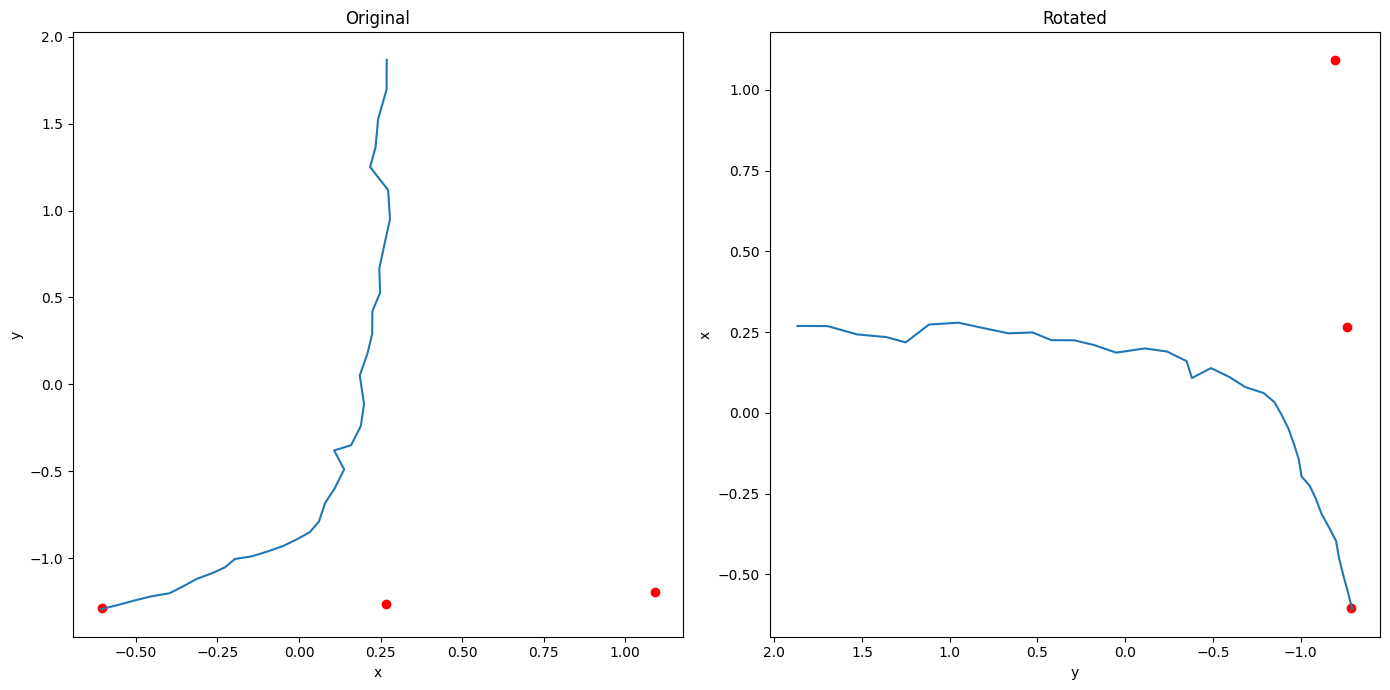

In [31]:
import matplotlib.pyplot as plt
import numpy as np

xs = np.array(xs)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# --- Original ---
ax = axes[0]
ax.scatter(1.093, -1.196, color='red')
ax.scatter(-0.605, -1.289, color='red')
ax.scatter(0.267, -1.267, color='red')

ax.plot(xs[:, 0], xs[:, 1])

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Original')

# --- Rotated ---
ax = axes[1]
ax.scatter(-1.196, 1.093, color='red')
ax.scatter(-1.289, -0.605, color='red')
ax.scatter(-1.267, 0.267, color='red')

# y on horizontal axis, x on vertical axis
ax.plot(xs[:, 1], xs[:, 0])

# Flip the vertical (x) axis
ax.invert_xaxis()

ax.set_xlabel('y')
ax.set_ylabel('x')
ax.set_title('Rotated')

plt.tight_layout()
plt.show()

In [32]:
xs_ex = xs.copy()

In [8]:
from joblib import Parallel, delayed
import numpy as np


def single_traj_k3(
    x0,
    nu,
    sigma_e,
    T,
    N=60,
    v0=3.5,
    k=3,
    r0=100,
    eta=0,
    eps=None,
    target_positions=None,
    t_max=5.0,
    step_interv = 0.05
):
    
    # ---------------------------------------------------------
    # Parameters
    # ---------------------------------------------------------
    
    if eps is None:
        eps = np.array([0.45, 0.45, 0.1])
    else:
        eps = np.asarray(eps)
    
    if target_positions is None:
        target_positions = np.array([
            [1.093, -1.196],
            [-0.605, -1.289],
            [0.267, -1.267]
        ])
    else:
        target_positions = np.asarray(target_positions)


    # ---------------------------------------------------------
    # Initial population
    # ---------------------------------------------------------
    
    N0_0 = 0
    N0_1 = N // 3
    
    N1_0 = 0
    N1_1 = N // 3
    
    N2_0 = 0
    N2_1 = N - N0_0 - N0_1 - N1_0 - N1_1 - N2_0


    n0 = N0_1 / N
    n1 = N1_1 / N
    n2 = N2_1 / N
    
    n = np.array([n0, n1, n2])


    # ---------------------------------------------------------
    # Initial position
    # ---------------------------------------------------------
    
    x = np.asarray(x0, dtype=float).copy()
    
    xs = [x.copy()]


    # ---------------------------------------------------------
    # Initial target vectors
    # ---------------------------------------------------------
    
    P0 = target_positions[0] - x
    P1 = target_positions[1] - x
    P2 = target_positions[2] - x


    # Unit vectors
    p0 = P0 / np.linalg.norm(P0)
    p1 = P1 / np.linalg.norm(P1)
    p2 = P2 / np.linalg.norm(P2)
    
    p = np.array([p0, p1, p2])


    # ---------------------------------------------------------
    # Time evolution
    # ---------------------------------------------------------
    
    t = 0.0
    step_err = np.random.normal(0, step_interv/10)
    step_interval = step_interv + step_err
    steps = 0


    while (
        np.linalg.norm(P0) > 0.1
        and np.linalg.norm(P1) > 0.1
        and np.linalg.norm(P2) > 0.1
        and t < t_max
    ):
        
        # -----------------------------------------------------
        # Gillespie time step
        # -----------------------------------------------------
        
        dt_ = dt(
            n, p, k, T, N, nu,
            r0, eta, eps
        )
        
        next_spatial_update = (steps + 1) * step_interval


        # -----------------------------------------------------
        # Spatial update
        # -----------------------------------------------------
        
        if t + dt_ >= next_spatial_update:
            
            t = next_spatial_update

            # Velocity
            Vel = V(n, p, k, v0)

            # Update position
            x += Vel * step_interval

            # Update target vectors
            P0 -= Vel * step_interval
            P1 -= Vel * step_interval
            P2 -= Vel * step_interval


            # -------------------------------------------------
            # Recalculate unit vectors
            # -------------------------------------------------
            
            p0 = P0 / np.linalg.norm(P0)
            p1 = P1 / np.linalg.norm(P1)
            p2 = P2 / np.linalg.norm(P2)


            # Add angular noise
            for p_vec in [p0, p1, p2]:
                
                angle = np.random.normal(0, sigma_e)
                
                cos_a = np.cos(angle)
                sin_a = np.sin(angle)
                
                p_vec[:] = np.array([
                    cos_a * p_vec[0] - sin_a * p_vec[1],
                    sin_a * p_vec[0] + cos_a * p_vec[1]
                ])


            p = np.array([p0, p1, p2])


            # Store position
            xs.append(x.copy())

            steps += 1
            
            continue


        # -----------------------------------------------------
        # Gillespie event
        # -----------------------------------------------------
        
        t += dt_
        
        alpha = np.random.uniform()


        # Calculate total rate ONCE
        Rtot = R_tot(
            n, p, k, T, N, nu,
            r0, eta, eps
        )


        # Transition probabilities
        p1_thres = (
            r_10(0, n, p, k, T, N, nu, r0, eta, eps)
            / Rtot
        )

        p2_thres = (
            p1_thres
            + r_01(0, n, p, k, T, N, nu, r0, eta, eps)
            / Rtot
        )

        p3_thres = (
            p2_thres
            + r_10(1, n, p, k, T, N, nu, r0, eta, eps)
            / Rtot
        )

        p4_thres = (
            p3_thres
            + r_01(1, n, p, k, T, N, nu, r0, eta, eps)
            / Rtot
        )

        p5_thres = (
            p4_thres
            + r_10(2, n, p, k, T, N, nu, r0, eta, eps)
            / Rtot
        )


        # -----------------------------------------------------
        # Execute event
        # -----------------------------------------------------
        
        if alpha <= p1_thres:
            
            N0_0 += 1
            N0_1 -= 1

        elif alpha <= p2_thres:
            
            N0_0 -= 1
            N0_1 += 1

        elif alpha <= p3_thres:
            
            N1_1 -= 1
            N1_0 += 1

        elif alpha <= p4_thres:
            
            N1_1 += 1
            N1_0 -= 1

        elif alpha <= p5_thres:
            
            N2_1 -= 1
            N2_0 += 1

        else:
            
            N2_1 += 1
            N2_0 -= 1


        # -----------------------------------------------------
        # Update occupation fractions
        # -----------------------------------------------------
        
        n0 = N0_1 / N
        n1 = N1_1 / N
        n2 = N2_1 / N
        
        n = np.array([n0, n1, n2])


    return xs


# =============================================================
# Parallel runner
# =============================================================

def run_simul_k3(
    x0,
    nu,
    sigma_e,
    T,
    num_trajs=500,
    N=60,
    v0=3.5,
    k=3,
    r0=100,
    eta=0,
    eps=None,
    target_positions=None,
    t_max=5.0,
    step_interv = 0.05,
    n_jobs=16
):
    
    if eps is None:
        eps = np.array([0.45, 0.45, 0.1])
    
    if target_positions is None:
        target_positions = np.array([
            [1.093, -1.196],
            [-0.605, -1.289],
            [0.267, -1.267]
        ])


    results = Parallel(
        n_jobs=n_jobs,
        backend="loky"
    )(
        delayed(single_traj_k3)(
            x0,
            nu,
            sigma_e,
            T,
            N,
            v0,
            k,
            r0,
            eta,
            eps,
            target_positions,
            t_max,
            step_interv
        )
        for _ in range(num_trajs)
    )


    return results

In [44]:
x0 = [0.269, 1.868]

nu = 0.1
sigma_e = 0.05
T = 0.3

N = 60
k = 3

v0 = 3.5
r0 = 100
eta = 0

eps = [0.45, 0.45, 0.28]

target_positions = np.array([
    [1.093, -1.196],
    [-0.605, -1.289],
    [0.267, -1.267]
])

step_interval = 0.05

trajs = run_simul_k3(
    x0=x0,
    nu=nu,
    sigma_e=sigma_e,
    T=T,
    num_trajs=500,
    N=N,
    v0=v0,
    k=k,
    r0=r0,
    eta=eta,
    eps=eps,
    target_positions=target_positions,
    t_max=5.0,
    step_interv = step_interval,
    n_jobs=16
)

Total trajectories: 500
  Target 1 (x>0): 196 trajectories (39.20%)
  Target 2 (x<0): 185 trajectories (37.00%)
  Target 3 (mid): 119 trajectories (23.80%)
  No target hit: 0 trajectories (0.00%)


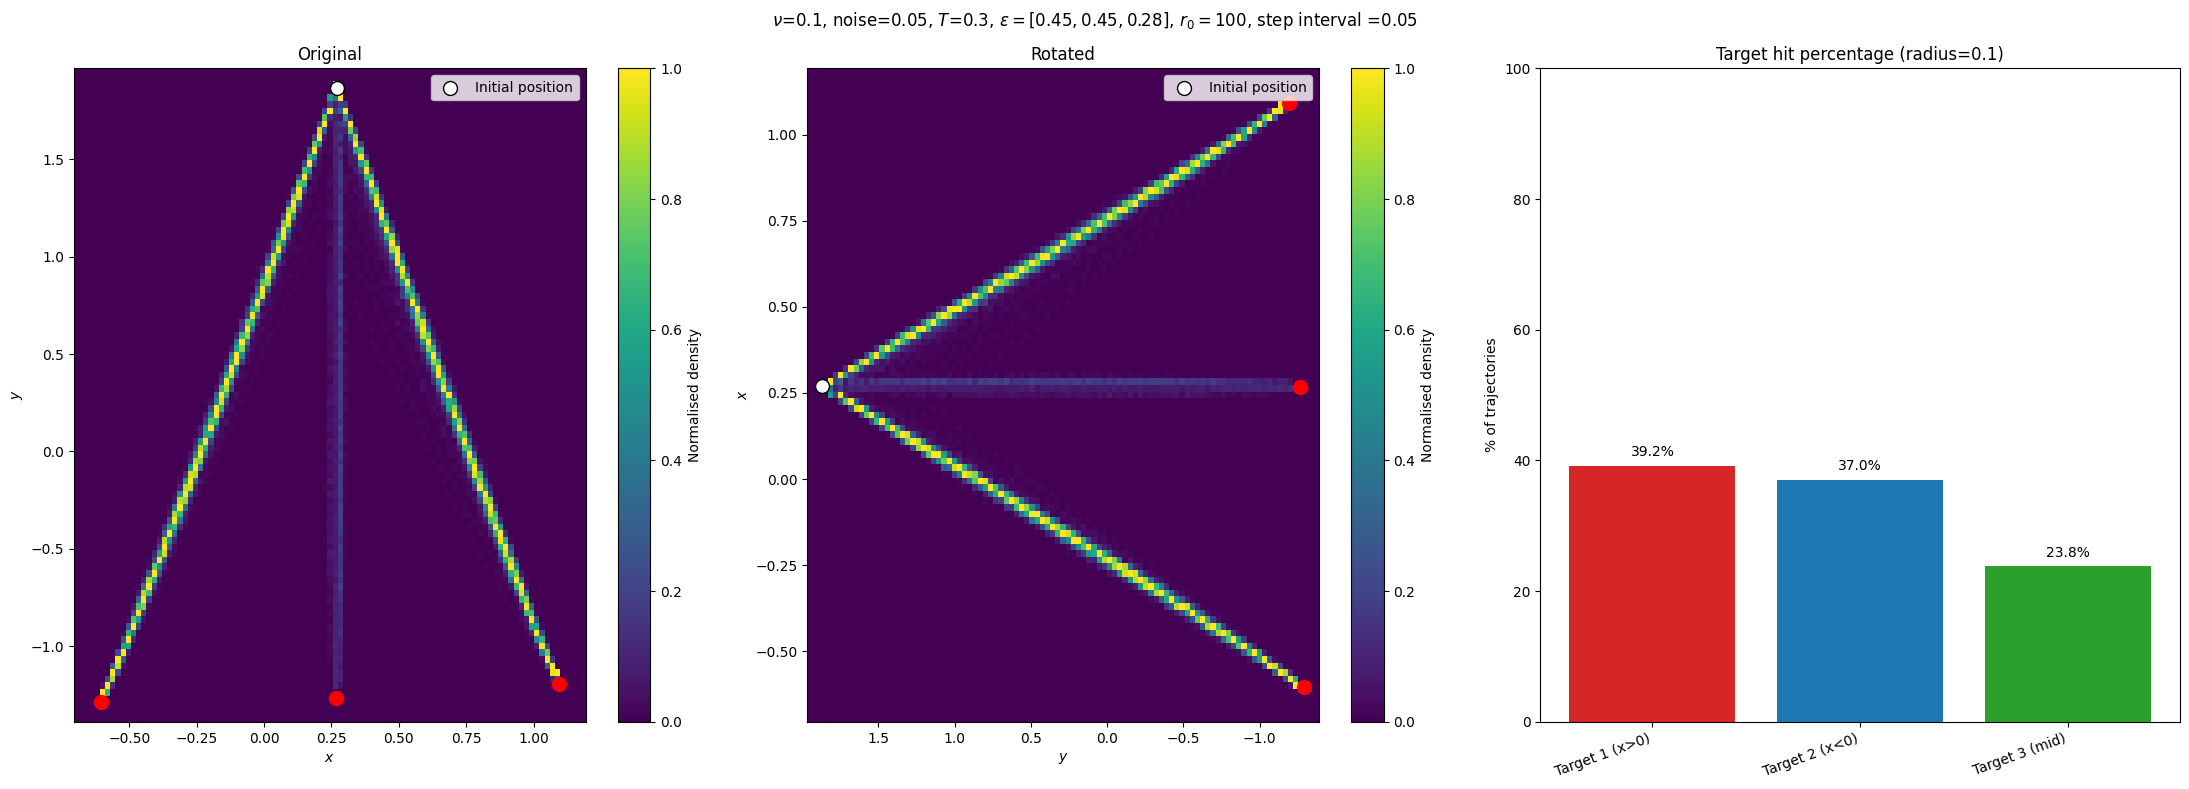

In [45]:
import matplotlib.pyplot as plt
import numpy as np

bins = 100

# ------------------------------------------------------------
# Target definitions
# ------------------------------------------------------------
# Target 1: x > 0
# Target 2: x < 0
# Target 3: middle (x ~ 0.267)

targets = {
    'Target 1 (x>0)':  (1.093, -1.196),
    'Target 2 (x<0)':  (-0.605, -1.289),
    'Target 3 (mid)':  (0.267, -1.267),
}

hit_radius = 0.1  # <-- tune this: distance threshold to count as "hitting" a target

# ------------------------------------------------------------
# Determine which target (if any) each trajectory hits
# ------------------------------------------------------------
# If a trajectory comes within hit_radius of multiple targets,
# we assign it to whichever target it reaches FIRST in time.

hit_counts = {name: 0 for name in targets}
no_hit_count = 0

for traj in trajs:
    traj = np.asarray(traj)  # shape (T, 2)

    first_hit_name = None
    first_hit_time = np.inf

    for name, (tx, ty) in targets.items():
        d = np.sqrt((traj[:, 0] - tx)**2 + (traj[:, 1] - ty)**2)
        idx = np.where(d <= hit_radius)[0]
        if len(idx) > 0 and idx[0] < first_hit_time:
            first_hit_time = idx[0]
            first_hit_name = name

    if first_hit_name is not None:
        hit_counts[first_hit_name] += 1
    else:
        no_hit_count += 1

n_traj = len(trajs)
hit_pcts = {name: 100 * count / n_traj for name, count in hit_counts.items()}
no_hit_pct = 100 * no_hit_count / n_traj

print(f"Total trajectories: {n_traj}")
for name, pct in hit_pcts.items():
    print(f"  {name}: {hit_counts[name]} trajectories ({pct:.2f}%)")
print(f"  No target hit: {no_hit_count} trajectories ({no_hit_pct:.2f}%)")

# ------------------------------------------------------------
# Spatial range
# ------------------------------------------------------------

x_edges = np.linspace(
    min(x0[0], 1.093, -0.605, 0.267) - 0.1,
    max(x0[0], 1.093, -0.605, 0.267) + 0.1,
    bins
)

y_edges = np.linspace(
    min(x0[1], -1.196, -1.289, -1.267) - 0.1,
    max(x0[1], -1.196, -1.289, -1.267) + 0.1,
    bins
)

# ------------------------------------------------------------
# Count trajectories passing through each bin
# ------------------------------------------------------------

H = np.zeros((bins - 1, bins - 1))

for traj in trajs:

    traj = np.asarray(traj)

    h, _, _ = np.histogram2d(
        traj[:, 0],
        traj[:, 1],
        bins=[x_edges, y_edges]
    )

    H += (h > 0).astype(float)

# H is currently [x_bin, y_bin]

# ------------------------------------------------------------
# Build ORIGINAL orientation (rows = y, cols = x -> needs transpose)
# ------------------------------------------------------------

H_orig = H.T  # now [y_bin, x_bin]
col_max = H_orig.max(axis=0, keepdims=True)
col_max[col_max == 0] = 1
H_orig = H_orig / col_max

# ------------------------------------------------------------
# Build ROTATED orientation (rows = x, cols = y -> no transpose)
# ------------------------------------------------------------

H_rot = H.copy()  # [x_bin, y_bin]
row_max = H_rot.max(axis=1, keepdims=True)
row_max[row_max == 0] = 1
H_rot = H_rot / row_max

# ------------------------------------------------------------
# Plot side by side (now 3 panels)
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# --- Original ---
ax = axes[0]
im0 = ax.imshow(
    H_orig,
    origin='lower',
    aspect='auto',
    extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
    cmap='viridis',
    vmin=0,
    vmax=1
)

ax.scatter(1.093, -1.196, s=100, color='red')
ax.scatter(-0.605, -1.289, s=100, color='red')
ax.scatter(0.267, -1.267, s=100, color='red')

ax.scatter(
    x0[0], x0[1],
    s=100,
    color='white',
    edgecolor='black',
    label='Initial position'
)

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Original')
ax.legend()
fig.colorbar(im0, ax=ax, label='Normalised density')

# --- Rotated ---
ax = axes[1]
im1 = ax.imshow(
    H_rot,
    origin='lower',
    aspect='auto',
    extent=[y_edges[0], y_edges[-1], x_edges[0], x_edges[-1]],
    cmap='viridis',
    vmin=0,
    vmax=1
)

ax.scatter(-1.196, 1.093, s=100, color='red')
ax.scatter(-1.289, -0.605, s=100, color='red')
ax.scatter(-1.267, 0.267, s=100, color='red')

ax.scatter(
    x0[1], x0[0],
    s=100,
    color='white',
    edgecolor='black',
    label='Initial position'
)

ax.invert_xaxis()

ax.set_xlabel('$y$')
ax.set_ylabel('$x$')
ax.set_title('Rotated')
ax.legend()
fig.colorbar(im1, ax=ax, label='Normalised density')

# --- Target-hit percentages ---
ax = axes[2]

labels = list(targets.keys())
pcts = [hit_pcts[name] for name in targets]
colors = ['tab:red', 'tab:blue', 'tab:green']

bars = ax.bar(labels, pcts, color=colors)
ax.set_ylabel('% of trajectories')
ax.set_title(f'Target hit percentage (radius={hit_radius})')
ax.set_ylim(0, 100)

for bar, pct in zip(bars, pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{pct:.1f}%',
        ha='center', va='bottom'
    )

plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

fig.suptitle(
    fr'$\nu$={nu}, noise={sigma_e}, $T$={T}, $\epsilon={eps}$, $r_0 ={r0}$, step interval ={step_interval}'
)

plt.tight_layout()
plt.show()

## PORTING BIFURCATION FINDING METHOD

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.signal import savgol_filter, find_peaks

# ======================================================================
# TARGETS (fixed for your experiment)
# ======================================================================
targets = np.array([
    [1.093, -1.196],
    [-0.605, -1.289],
    [0.267, -1.267]
])

# ======================================================================
# 1. NEW EXPERIMENTAL BIFURCATION DETECTION (Ported to Sim)
# ======================================================================

def critical_angle_between_targets(position, target_i, target_j):
    vi = target_i - position
    vj = target_j - position
    vi = vi / (np.linalg.norm(vi) + 1e-12)
    vj = vj / (np.linalg.norm(vj) + 1e-12)
    cos_theta = np.clip(np.dot(vi, vj), -1.0, 1.0)
    return np.degrees(np.arccos(cos_theta))

def find_bifurcations(
    xs,
    targets,
    required_hold_steps=15,
    window_size=25,
    min_corr_threshold=0.8,
    plateau_hold_steps=1000,
    next_start=500,          
    trajectory_fraction=0.85,
    angles_deg=None,
    corr_smooth_win=1        # Retained for simulation smoothing
):
    xs = np.asarray(xs)
    targets = np.asarray(targets)
    num_targets = targets.shape[0]
    N_full = len(xs)

    if num_targets not in (2, 3):
        raise ValueError("find_bifurcations currently supports only 2 or 3 targets")

    # ---------- velocities, positions, distances ----------
    velocities = np.diff(xs, axis=0)
    vel_norms = np.linalg.norm(velocities, axis=1, keepdims=True)
    vel_units = velocities / (vel_norms + 1e-12)
    positions = xs[:-1]
    x_coords = positions[:, 0]

    step_lengths = np.linalg.norm(velocities, axis=1)
    distance = np.concatenate([[0], np.cumsum(step_lengths)])[:-1]

    # ---------- angles (or use supplied) ----------
    if angles_deg is None:
        angles_deg = np.zeros((len(positions), num_targets))
        for i, target in enumerate(targets):
            dir_to_target = target - positions
            dir_norms = np.linalg.norm(dir_to_target, axis=1, keepdims=True)
            dir_units = dir_to_target / (dir_norms + 1e-12)
            dots = np.sum(vel_units * dir_units, axis=1)
            dots = np.clip(dots, -1, 1)
            angles_deg[:, i] = np.degrees(np.arccos(dots))
    else:
        if len(angles_deg) != len(positions):
            raise ValueError("Supplied angles_deg must have length N-1")

    # ---------- pairwise angle differences ----------
    diff_labels = []
    diff_curves = []
    for i in range(num_targets):
        for j in range(i + 1, num_targets):
            diff_curves.append(np.abs(angles_deg[:, i] - angles_deg[:, j]))
            diff_labels.append(f"|{i}-{j}|")
    diff_curves = np.column_stack(diff_curves)

    # ---------- rolling Pearson correlation (CENTERED window) ----------
    n_points = len(positions)
    num_pairs = diff_curves.shape[1]
    pair_indices = [(i, j) for i in range(num_targets) for j in range(i + 1, num_targets)]

    pair_corr = np.full((n_points, num_pairs), np.nan)
    effective_window = min(window_size, n_points)
    if effective_window < 2:
        effective_window = 2
    half = effective_window // 2
    valid_start = half
    valid_end = n_points - half - (effective_window % 2 == 0)

    if valid_end >= valid_start:
        for p_idx, (i, j) in enumerate(pair_indices):
            a = angles_deg[:, i]
            b = angles_deg[:, j]
            for t in range(valid_start, valid_end + 1):
                start = t - half
                end = t + half + (effective_window % 2)
                a_win = a[start:end]
                b_win = b[start:end]
                corr = np.corrcoef(a_win, b_win)[0, 1]
                if np.isnan(corr):
                    corr = 0.0
                pair_corr[t, p_idx] = corr
                
        # Fill edges
        for p_idx in range(num_pairs):
            pair_corr[:valid_start, p_idx] = pair_corr[valid_start, p_idx]
            pair_corr[valid_end+1:, p_idx] = pair_corr[valid_end, p_idx]

    # -------- Optional correlation‑curve smoothing (Sim specific) --------
    if corr_smooth_win > 1:
        kernel_c = np.ones(corr_smooth_win) / corr_smooth_win
        for p in range(num_pairs):
            col = pair_corr[:, p].copy()
            col_sm = np.convolve(col, kernel_c, mode='same')
            half_c = corr_smooth_win // 2
            if half_c > 0:
                col_sm[:half_c] = col[:half_c]
                col_sm[-half_c:] = col[-half_c:]
            pair_corr[:, p] = col_sm

    # ---------- standard bifurcation detection ----------
    if num_targets == 2:
        closest_line_idx = np.argmin(angles_deg, axis=1)
        standard_bif_tagged = []
        current_color = closest_line_idx[0]
        hold_count = 0
        for i in range(1, len(closest_line_idx)):
            if closest_line_idx[i] != current_color:
                hold_count += 1
                if hold_count >= required_hold_steps:
                    bif_idx = i - required_hold_steps + 1
                    standard_bif_tagged.append({
                        "index": bif_idx, "pair": (0, 1), "source": "standard"
                    })
                    current_color = closest_line_idx[i]
                    hold_count = 0
            else:
                hold_count = 0
    else:
        if valid_end < valid_start:
            standard_bif_tagged = []
        else:
            outlier_idx_full = np.full(n_points, -1, dtype=int)
            for t in range(valid_start, valid_end + 1):
                row = pair_corr[t]
                if np.all(np.isnan(row)):
                    continue
                best_pair = np.nanargmax(row)
                outlier_map = [2, 1, 0]  # (0,1)->2, (0,2)->1, (1,2)->0
                outlier_idx_full[t] = outlier_map[best_pair]

            standard_bif_tagged = []
            first_valid = valid_start
            current_outlier = outlier_idx_full[first_valid]
            hold_count = 0
            for i in range(first_valid + 1, valid_end + 1):
                if outlier_idx_full[i] == -1:
                    continue
                if outlier_idx_full[i] != current_outlier:
                    hold_count += 1
                    if hold_count >= required_hold_steps:
                        bif_idx = i - required_hold_steps + 1
                        old_pair_k = outlier_map.index(current_outlier)
                        i_t, j_t = pair_indices[old_pair_k]
                        standard_bif_tagged.append({
                            "index": bif_idx, "pair": (i_t, j_t), "source": "standard"
                        })
                        current_outlier = outlier_idx_full[i]
                        hold_count = 0
                else:
                    hold_count = 0

    # ---------- Plateau‑exit detection (global scan) ----------
    min_corr = np.nanmin(pair_corr, axis=1)
    plateau_bif = None
    start_scan = valid_start
    plateau_start = None
    plateau_len = 0
    for t in range(start_scan, valid_end + 1):
        if min_corr[t] >= min_corr_threshold:
            if plateau_start is None:
                plateau_start = t
            plateau_len += 1
        else:
            if plateau_len >= plateau_hold_steps and plateau_start is not None:
                plateau_bif = t
                break
            else:
                plateau_start = None
                plateau_len = 0

    plateau_tagged = []
    if plateau_bif is not None:
        plateau_tagged.append({
            "index": plateau_bif, "pair": (0, 1), "source": "plateau"
        })

    # ---------- Merge (plateau wins) ----------
    all_tagged = standard_bif_tagged + plateau_tagged
    all_tagged.sort(key=lambda b: b["index"])
    final_bif_tagged = []
    for b in all_tagged:
        if not final_bif_tagged:
            final_bif_tagged.append(b)
            continue
        if b["index"] - final_bif_tagged[-1]["index"] <= required_hold_steps:
            if b["source"] == "plateau" and final_bif_tagged[-1]["source"] != "plateau":
                final_bif_tagged[-1] = b
        else:
            final_bif_tagged.append(b)
    final_bif_tagged = final_bif_tagged[:2]

    max_allowed_index = int(N_full * trajectory_fraction)
    final_bif_tagged = [b for b in final_bif_tagged if b["index"] < max_allowed_index]

    # ---------- Chronological roles ----------
    for i, b in enumerate(final_bif_tagged):
        b["role"] = "first" if i == 0 else "second"

    # ---------- Typology & Pair Assignment ----------
    for b in final_bif_tagged:
        idx = b["index"]
        if num_targets == 3:
            corrs = pair_corr[idx]
            if np.all(np.isnan(corrs)):
                min_pair = b["pair"]
            else:
                min_pair_idx = np.nanargmin(corrs)
                min_pair = pair_indices[min_pair_idx]
            
            b["typology"] = "edge-pair" if min_pair == (0, 1) else "edge-center"
            b["pair"] = min_pair 
        else:
            b["typology"] = "edge-pair"

    # ---------- Attach critical angle ----------
    for b in final_bif_tagged:
        idx = b["index"]
        i_t, j_t = b["pair"]
        b["critical_angle_deg"] = critical_angle_between_targets(
            positions[idx], targets[i_t], targets[j_t]
        )

    return {
        "positions": positions,
        "angles_deg": angles_deg,
        "diff_curves": diff_curves,
        "diff_labels": diff_labels,
        "bif_indices": [b["index"] for b in final_bif_tagged],
        "bifurcations": final_bif_tagged,
        "distance": distance,
        "pair_corr": pair_corr,
        "x_coords": x_coords
    }


In [33]:
len(xs)

37

BIFURCATION DETECTION RESULTS
RAW METHOD:
  None detected.

DERIVATIVE METHOD:
  None detected.


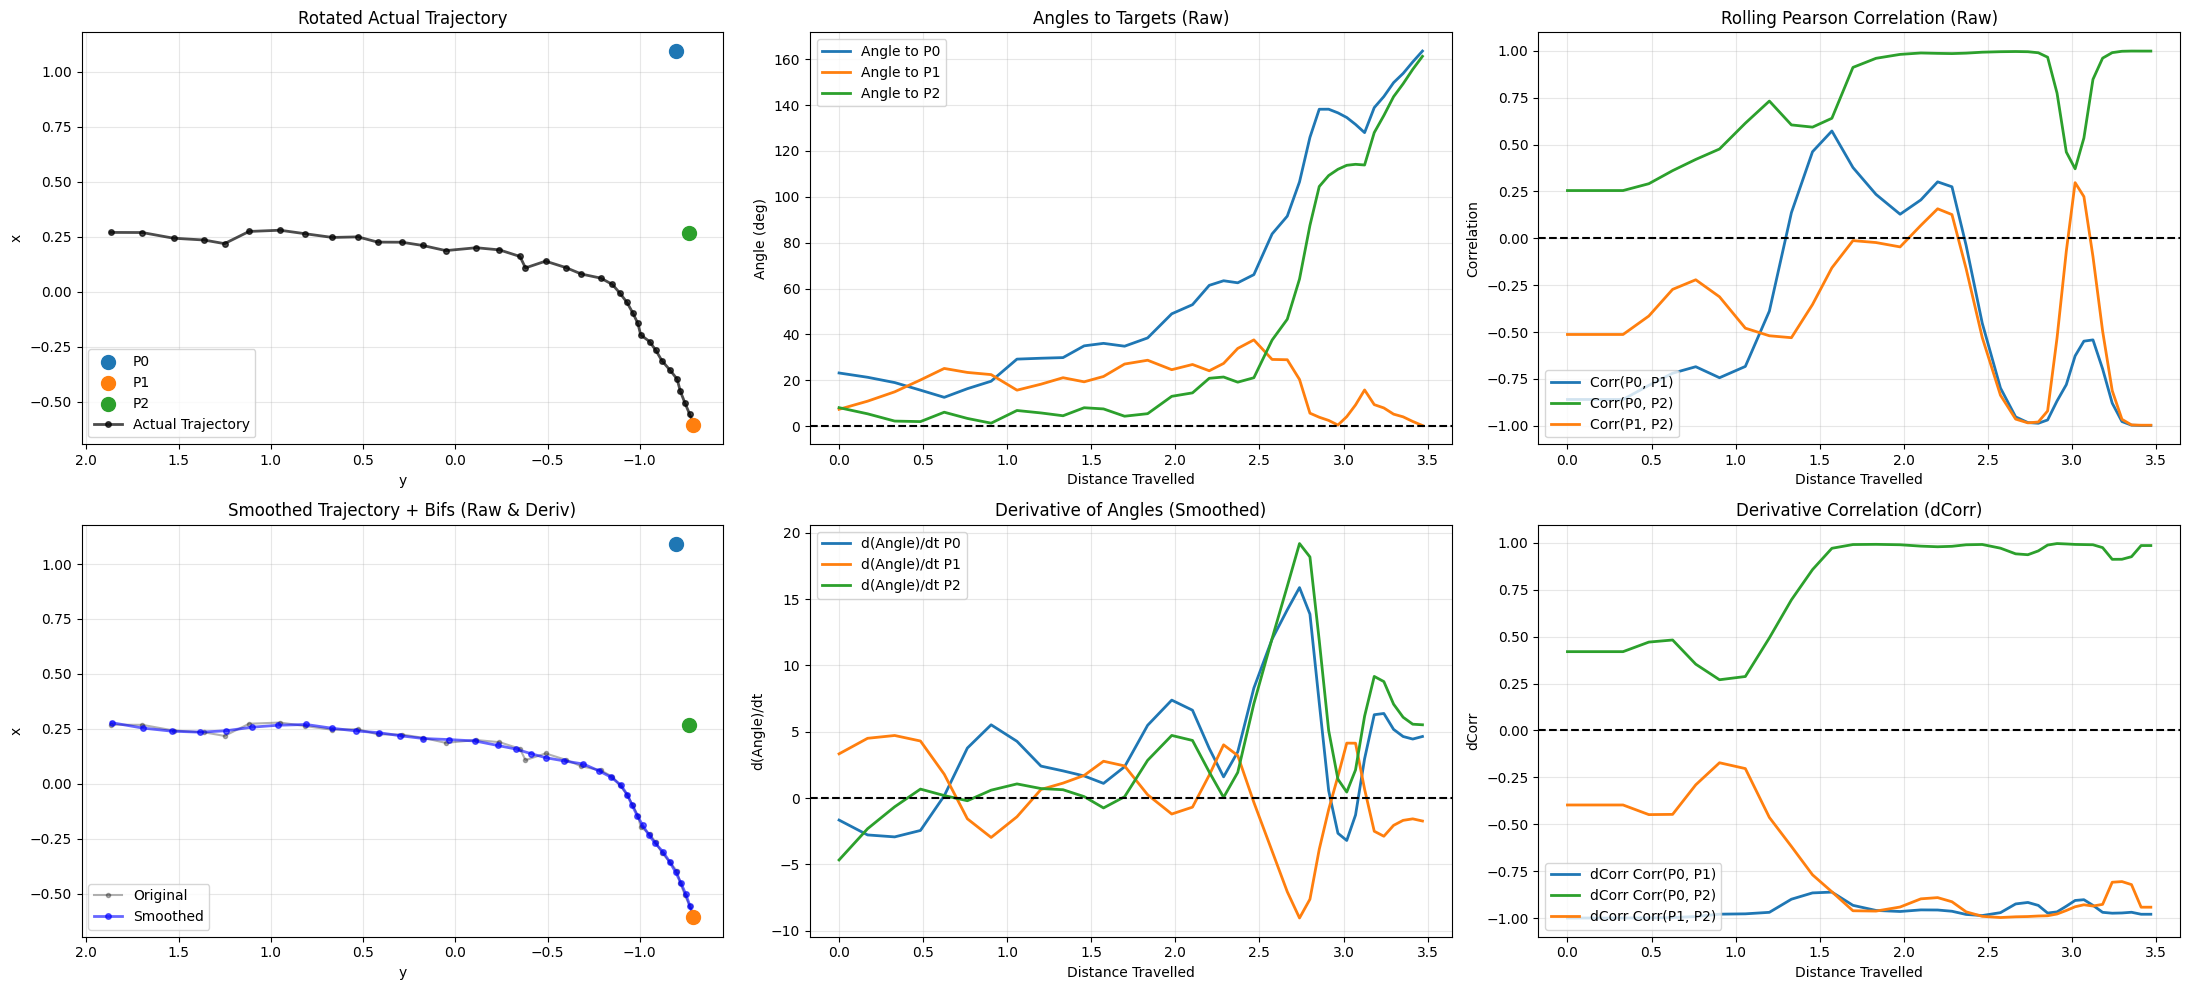

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks

xs = xs_ex.copy()
# Convert simulated list to numpy array
xs = np.array(xs)
N_pts = len(xs)

# ------------------------------------------------------------
# 1. Update Targets to new coordinate parameters
# ------------------------------------------------------------
targets = np.array([
    [1.093, -1.196],  # P0
    [-0.605, -1.289], # P1
    [0.267, -1.267]   # P2
])

# ------------------------------------------------------------
# 2. Dynamic Parameter Scaling
# ------------------------------------------------------------
def make_odd(val):
    return int(val) if int(val) % 2 != 0 else int(val) + 1

sw = max(3, make_odd(N_pts * 0.20))     
sw = min(15, sw)                       
poly = min(2, sw - 1)

win_size = max(3, make_odd(N_pts * 0.20))   
req_hold = max(2, int(N_pts * 0.03))        
corr_sw  = max(3, make_odd(N_pts * 0.05))   
plat_hold= max(2, int(N_pts * 0.05))        
dist_pks = max(2, int(N_pts * 0.10))        

ang_sw = max(3, make_odd(N_pts * 0.15))
ang_poly = min(2, ang_sw - 1)

# ------------------------------------------------------------
# 3. Apply Smoothing & Run RAW PCC Detection
# ------------------------------------------------------------
xs_smooth = savgol_filter(xs, window_length=sw, polyorder=poly, axis=0)

results_raw = find_bifurcations(
    xs_smooth, targets,
    window_size=win_size,          
    required_hold_steps=req_hold,
    corr_smooth_win=corr_sw,      
    min_corr_threshold=0.6,
    plateau_hold_steps=plat_hold
)

bif_idx_raw = results_raw["bif_indices"]
distance = results_raw["distance"]  
angles = results_raw["angles_deg"]
pair_corr_raw = results_raw["pair_corr"]
bif_meta_raw = results_raw["bifurcations"]

# ------------------------------------------------------------
# 4. Run DERIVATIVE PCC Detection
# ------------------------------------------------------------
angles_smooth = savgol_filter(angles, window_length=ang_sw, polyorder=ang_poly, axis=0)
d1_angles = np.gradient(angles_smooth, axis=0)
d1_smooth = savgol_filter(d1_angles, window_length=ang_sw, polyorder=ang_poly, axis=0)

results_deriv = find_bifurcations(
    xs_smooth, targets,
    window_size=win_size,          
    required_hold_steps=req_hold,
    corr_smooth_win=corr_sw,      
    min_corr_threshold=0.6,
    plateau_hold_steps=plat_hold,
    angles_deg=d1_smooth  
)

bif_idx_der = results_deriv["bif_indices"]
pair_corr_der = results_deriv["pair_corr"]
bif_meta_der = results_deriv["bifurcations"]

# ------------------------------------------------------------
# PRINT OUTPUT TO CONSOLE
# ------------------------------------------------------------
print("="*40)
print("BIFURCATION DETECTION RESULTS")
print("="*40)
print("RAW METHOD:")
for i, b in enumerate(bif_meta_raw):
    print(f"  Bifurcation {i+1} | {b['typology'].upper()} | Critical Angle: {b['critical_angle_deg']:.1f}°")
if not bif_meta_raw:
    print("  None detected.")

print("\nDERIVATIVE METHOD:")
for i, b in enumerate(bif_meta_der):
    print(f"  Bifurcation {i+1} | {b['typology'].upper()} | Critical Angle: {b['critical_angle_deg']:.1f}°")
if not bif_meta_der:
    print("  None detected.")
print("="*40)

# ------------------------------------------------------------
# EXACT CROSSING INTERPOLATOR
# ------------------------------------------------------------
def exact_crossing(idx, dist_arr, traj_arr, corr_arr):
    """Calculates the exact sub-index intersection of the correlation curves."""
    if idx <= 0 or idx >= len(dist_arr):
        return dist_arr[idx], traj_arr[idx, 1], traj_arr[idx, 0]
        
    row_after, row_before = corr_arr[idx], corr_arr[idx-1]
    max_after, max_before = np.nanargmax(row_after), np.nanargmax(row_before)
    
    # If the max pair didn't change (e.g. plateau exit), don't interpolate
    if max_after == max_before:
        return dist_arr[idx], traj_arr[idx, 1], traj_arr[idx, 0]
        
    y1_b, y1_a = row_before[max_after], row_after[max_after]
    y2_b, y2_a = row_before[max_before], row_after[max_before]
    
    dy1, dy2 = y1_a - y1_b, y2_a - y2_b
    if dy1 == dy2:
        t = 0.5
    else:
        t = np.clip((y2_b - y1_b) / (dy1 - dy2), 0, 1)
        
    dist_c = dist_arr[idx-1] + t * (dist_arr[idx] - dist_arr[idx-1])
    bx = traj_arr[idx-1, 1] + t * (traj_arr[idx, 1] - traj_arr[idx-1, 1])
    by = traj_arr[idx-1, 0] + t * (traj_arr[idx, 0] - traj_arr[idx-1, 0])
    
    return dist_c, bx, by

# ------------------------------------------------------------
# 5. Plotting – SIX panels (2x3 Grid)
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(22, 10))

target_colors = ['tab:blue', 'tab:orange', 'tab:green']
target_labels = ['P0', 'P1', 'P2']
corr_colors = ['#1f77b4', '#2ca02c', '#ff7f0e']
corr_labels = ['Corr(P0, P1)', 'Corr(P0, P2)', 'Corr(P1, P2)']

def draw_interpolated_bifs(ax, b_idx_raw, b_idx_der, traj_array, corr_raw, corr_der):
    for idx in b_idx_raw:
        if idx < len(distance):
            _, bx, by = exact_crossing(idx, distance, traj_array, corr_raw)
            ax.plot(bx, by, marker='*', color='gold', ms=15, markeredgecolor='black', zorder=10)
            
    for idx in b_idx_der:
        if idx < len(distance):
            _, bx, by = exact_crossing(idx, distance, traj_array, corr_der)
            ax.plot(bx, by, marker='D', color='black', ms=9, markeredgecolor='white', zorder=11)

# ---------- PANEL 1 (0,0): Rotated Actual Trajectory ----------
ax0 = axes[0, 0]
for i in range(3):
    ax0.scatter(targets[i, 1], targets[i, 0], color=target_colors[i], s=100, zorder=5, label=target_labels[i])
ax0.plot(xs[:, 1], xs[:, 0], 'k-o', lw=2, markersize=4, alpha=0.7, label='Actual Trajectory')
draw_interpolated_bifs(ax0, bif_idx_raw, bif_idx_der, xs, pair_corr_raw, pair_corr_der)
ax0.invert_xaxis()
ax0.set_xlabel('y')
ax0.set_ylabel('x')
ax0.set_title('Rotated Actual Trajectory')
ax0.legend(loc='lower left')
ax0.grid(True, alpha=0.3)

# ---------- PANEL 2 (1,0): Smoothed Trajectory + ALL Bifurcations ----------
ax1 = axes[1, 0]
for i in range(3):
    ax1.scatter(targets[i, 1], targets[i, 0], color=target_colors[i], s=100, zorder=5)
ax1.plot(xs[:, 1], xs[:, 0], 'k-o', lw=1.5, markersize=3, alpha=0.3, label='Original')
ax1.plot(xs_smooth[:, 1], xs_smooth[:, 0], 'b-o', lw=2, markersize=4, alpha=0.6, label='Smoothed')
draw_interpolated_bifs(ax1, bif_idx_raw, bif_idx_der, xs_smooth, pair_corr_raw, pair_corr_der)
ax1.invert_xaxis()
ax1.set_xlabel('y')
ax1.set_ylabel('x')
ax1.set_title('Smoothed Trajectory + Bifs (Raw & Deriv)')
ax1.legend(loc='lower left')
ax1.grid(True, alpha=0.3)

# ---------- PANEL 3 (0,1): Angles with RAW lines ----------
ax2 = axes[0, 1]
for i in range(3):
    ax2.plot(distance, angles[:, i], color=target_colors[i], lw=2, label=f'Angle to {target_labels[i]}')
for idx in bif_idx_raw:
    if idx < len(distance):
        dist_c, _, _ = exact_crossing(idx, distance, xs_smooth, pair_corr_raw)
        ax2.axvline(x=dist_c, color='red', ls='--', alpha=0.5, lw=2)
ax2.axhline(0, color='black', ls='--')
ax2.set_xlabel('Distance Travelled')
ax2.set_ylabel('Angle (deg)')
ax2.set_title('Angles to Targets (Raw)')
ax2.grid(True, alpha=0.3)
ax2.legend()

# ---------- PANEL 4 (1,1): Deriv Angles with DERIV lines ----------
ax3 = axes[1, 1]
for i in range(3):
    ax3.plot(distance, d1_smooth[:, i], color=target_colors[i], lw=2, label=f'd(Angle)/dt {target_labels[i]}')
for idx in bif_idx_der:
    if idx < len(distance):
        dist_c, _, _ = exact_crossing(idx, distance, xs_smooth, pair_corr_der)
        ax3.axvline(x=dist_c, color='black', ls='--', alpha=0.5, lw=2)
ax3.axhline(0, color='black', ls='--')
ax3.set_xlabel('Distance Travelled')
ax3.set_ylabel('d(Angle)/dt')
ax3.set_title('Derivative of Angles (Smoothed)')
ax3.grid(True, alpha=0.3)
ax3.legend()

# ---------- PANEL 5 (0,2): Raw Correlation ----------
ax4 = axes[0, 2]
for p in range(3):
    ax4.plot(distance, pair_corr_raw[:, p], color=corr_colors[p], lw=2, label=corr_labels[p])
for idx in bif_idx_raw:
    if idx < len(distance):
        dist_c, _, _ = exact_crossing(idx, distance, xs_smooth, pair_corr_raw)
        ax4.axvline(x=dist_c, color='red', ls='--', alpha=0.5, lw=2)
ax4.axhline(0, color='black', ls='--')
ax4.set_xlabel('Distance Travelled')
ax4.set_ylabel('Correlation')
ax4.set_title('Rolling Pearson Correlation (Raw)')
ax4.grid(True, alpha=0.3)
ax4.legend(loc='lower left')

# ---------- PANEL 6 (1,2): Deriv Correlation ----------
ax5 = axes[1, 2]
for p in range(3):
    ax5.plot(distance, pair_corr_der[:, p], color=corr_colors[p], lw=2, label=f'dCorr {corr_labels[p]}')
for idx in bif_idx_der:
    if idx < len(distance):
        dist_c, _, _ = exact_crossing(idx, distance, xs_smooth, pair_corr_der)
        ax5.axvline(x=dist_c, color='black', ls='--', alpha=0.5, lw=2)
ax5.axhline(0, color='black', ls='--')
ax5.set_xlabel('Distance Travelled')
ax5.set_ylabel('dCorr')
ax5.set_title('Derivative Correlation (dCorr)')
ax5.grid(True, alpha=0.3)
ax5.legend(loc='lower left')

plt.tight_layout()
plt.show()

## PARAMETER SWEEP


Effect of nu
nu = 0.2 -> outputs_recovered\nu_0.20\sigma_0.10\eps_045_045_020\T0.3_r0100_step0.025.png
nu = 0.25 -> outputs_recovered\nu_0.25\sigma_0.10\eps_045_045_020\T0.3_r0100_step0.025.png
nu = 0.3 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.3_r0100_step0.025.png
nu = 0.35 -> outputs_recovered\nu_0.35\sigma_0.10\eps_045_045_020\T0.3_r0100_step0.025.png
nu = 0.4 -> outputs_recovered\nu_0.40\sigma_0.10\eps_045_045_020\T0.3_r0100_step0.025.png
nu = 0.45 -> outputs_recovered\nu_0.45\sigma_0.10\eps_045_045_020\T0.3_r0100_step0.025.png


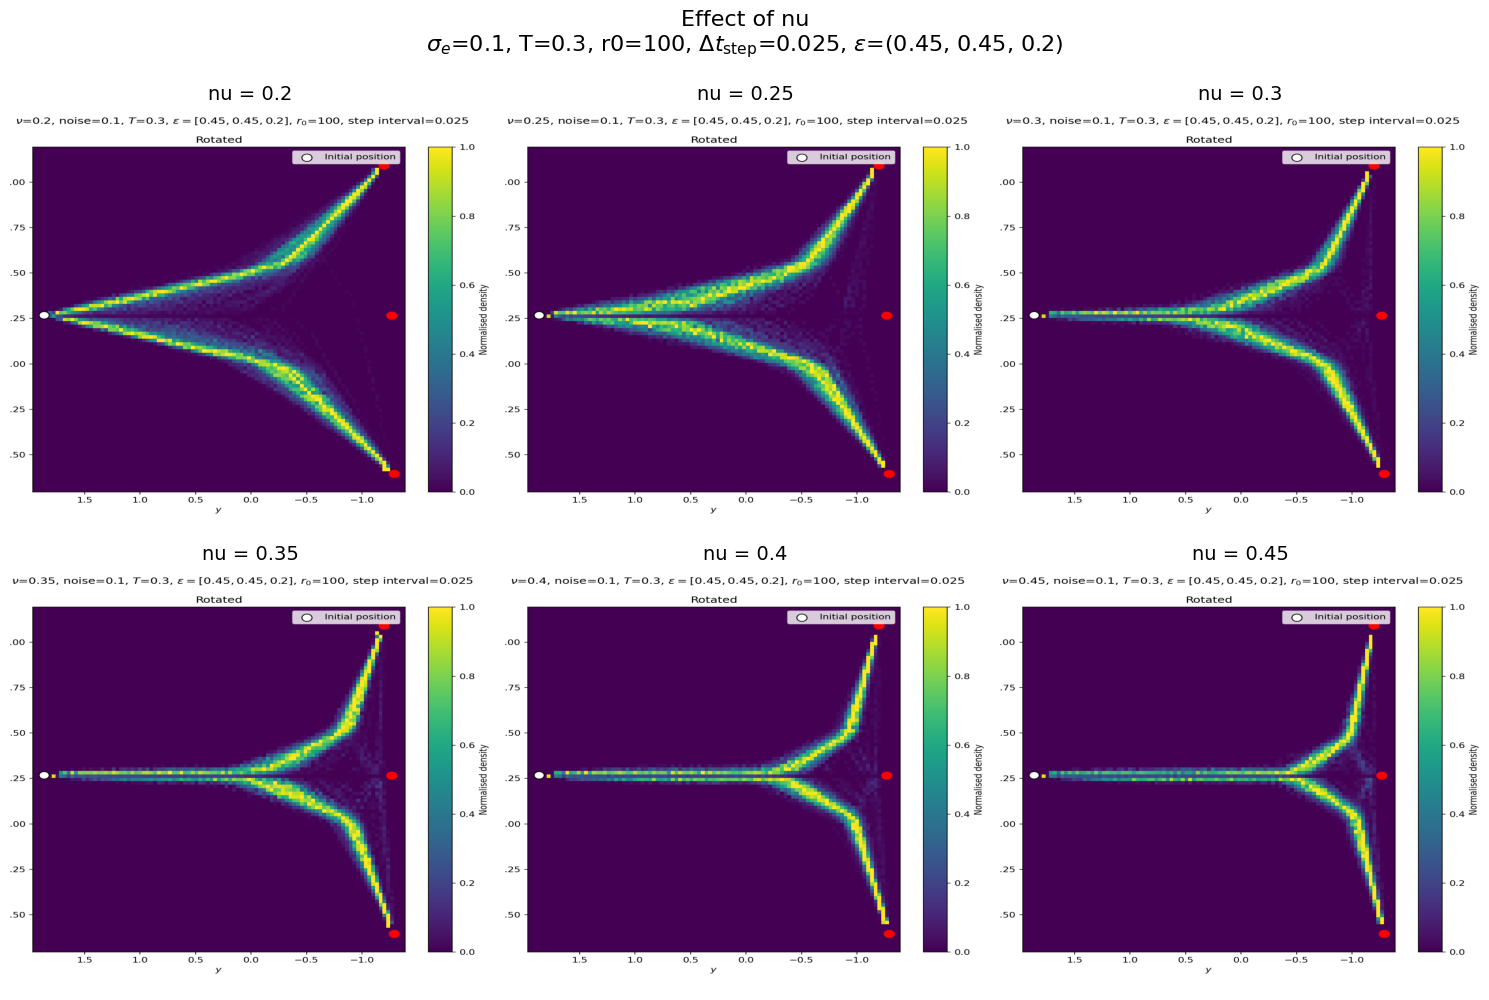


Effect of sigma_e
sigma_e = 0.1 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.3_r0100_step0.025.png
sigma_e = 0.2 -> outputs_recovered\nu_0.30\sigma_0.20\eps_045_045_020\T0.3_r0100_step0.025.png
sigma_e = 0.25 -> outputs_recovered\nu_0.30\sigma_0.25\eps_045_045_020\T0.3_r0100_step0.025.png
sigma_e = 0.35 -> outputs_recovered\nu_0.30\sigma_0.35\eps_045_045_020\T0.3_r00100_step0.025.png


C:\Users\iswav\AppData\Local\Temp\ipykernel_20736\1483844639.py:596: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


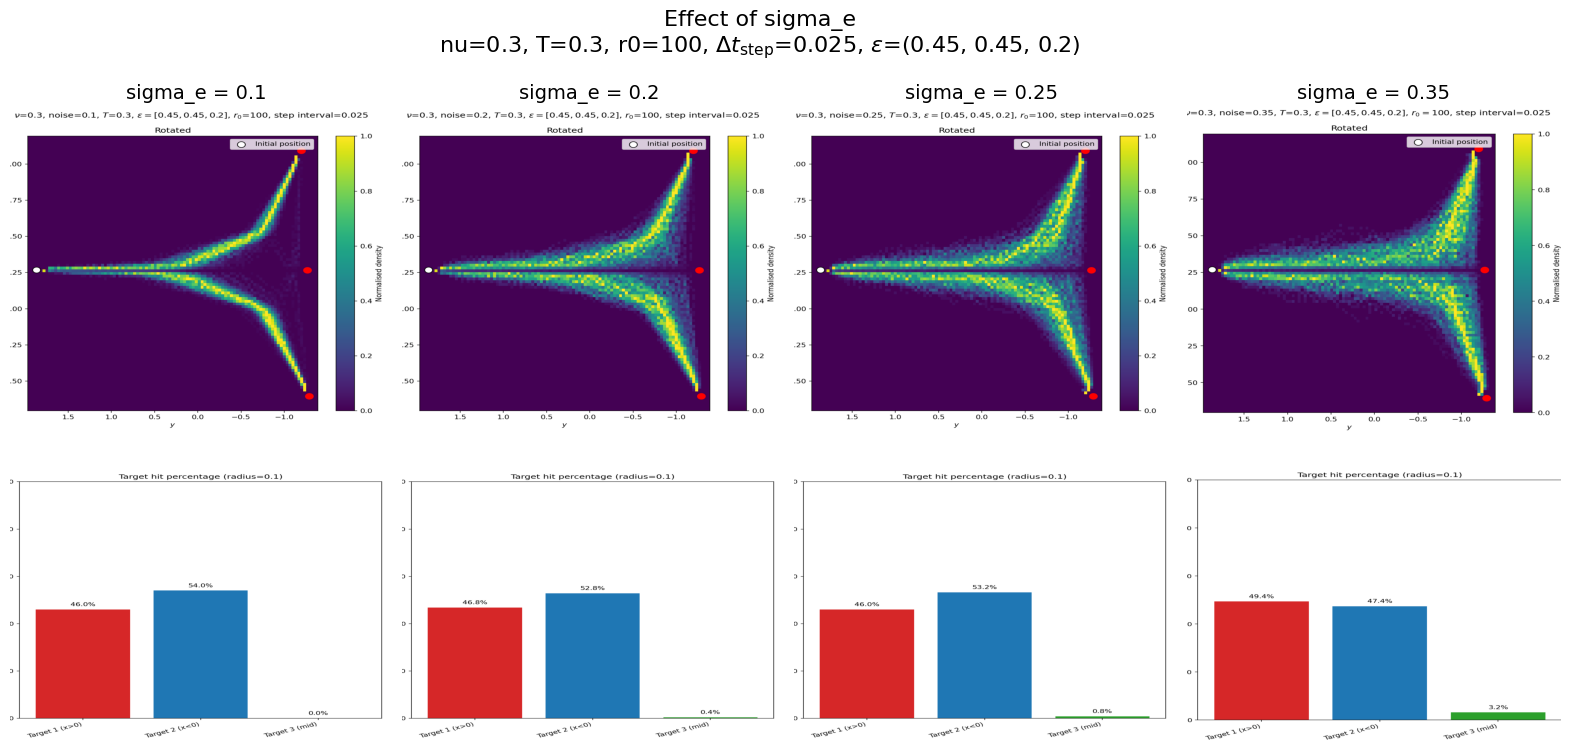


Effect of sigma_e
sigma_e = 0.5 -> outputs_recovered\nu_0.30\sigma_0.50\eps_045_045_020\T0.3_r00100_step0.025.png
sigma_e = 0.65 -> outputs_recovered\nu_0.30\sigma_0.65\eps_045_045_020\T0.3_r00100_step0.025.png
sigma_e = 0.8 -> outputs_recovered\nu_0.30\sigma_0.80\eps_045_045_020\T0.3_r00100_step0.025.png
sigma_e = 1.0 -> outputs_recovered\nu_0.30\sigma_1.00\eps_045_045_020\T0.3_r00100_step0.025.png


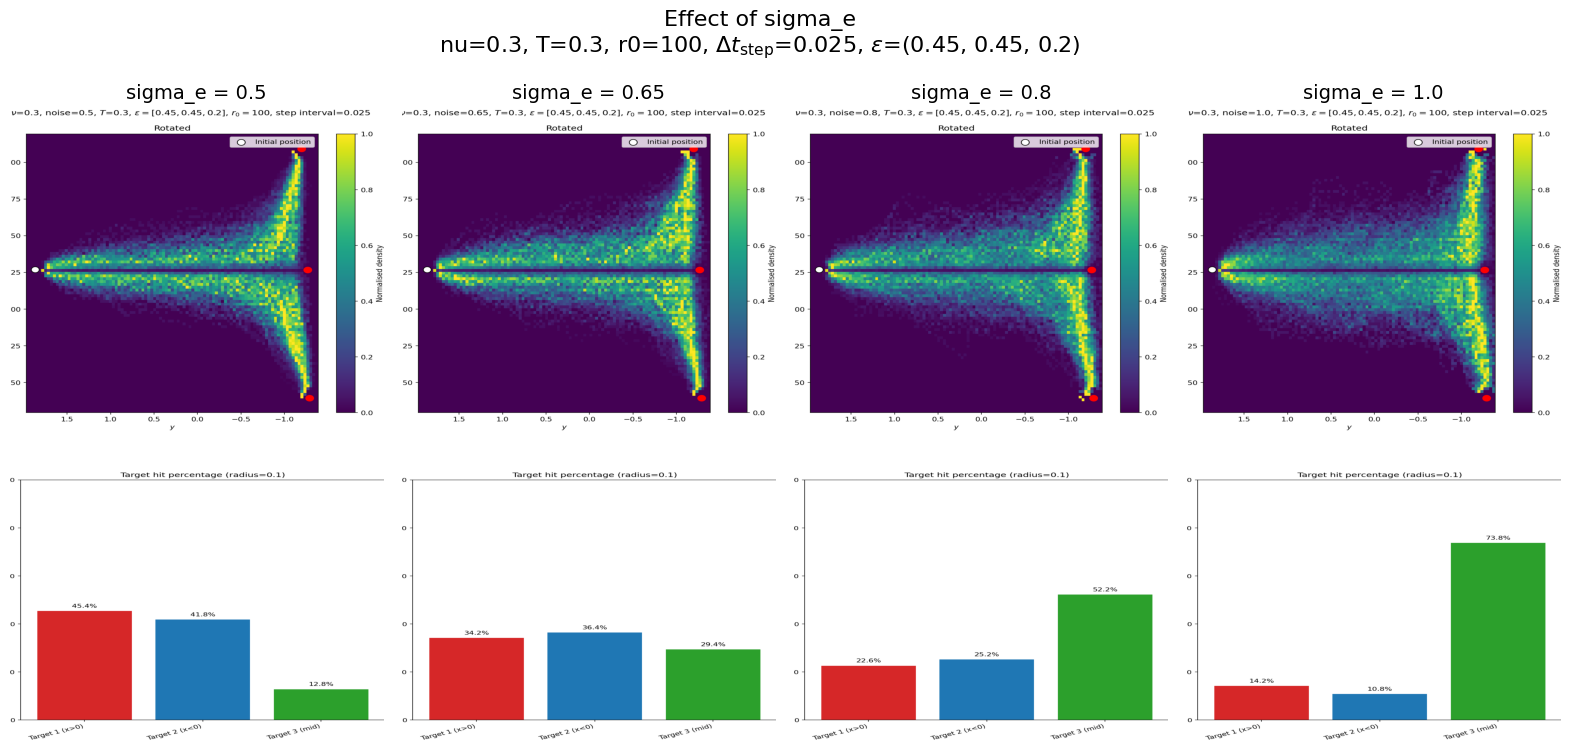


Effect of T
T = 0.1 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.1_r0100_step0.025.png
T = 0.2 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.2_r0100_step0.025.png
T = 0.3 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.3_r0100_step0.025.png
T = 0.4 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.4_r0100_step0.025.png
T = 0.5 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.5_r0100_step0.025.png
T = 0.6 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.6_r00100_step0.025.png
T = 0.7 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.7_r00100_step0.025.png
T = 0.8 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.8_r00100_step0.025.png


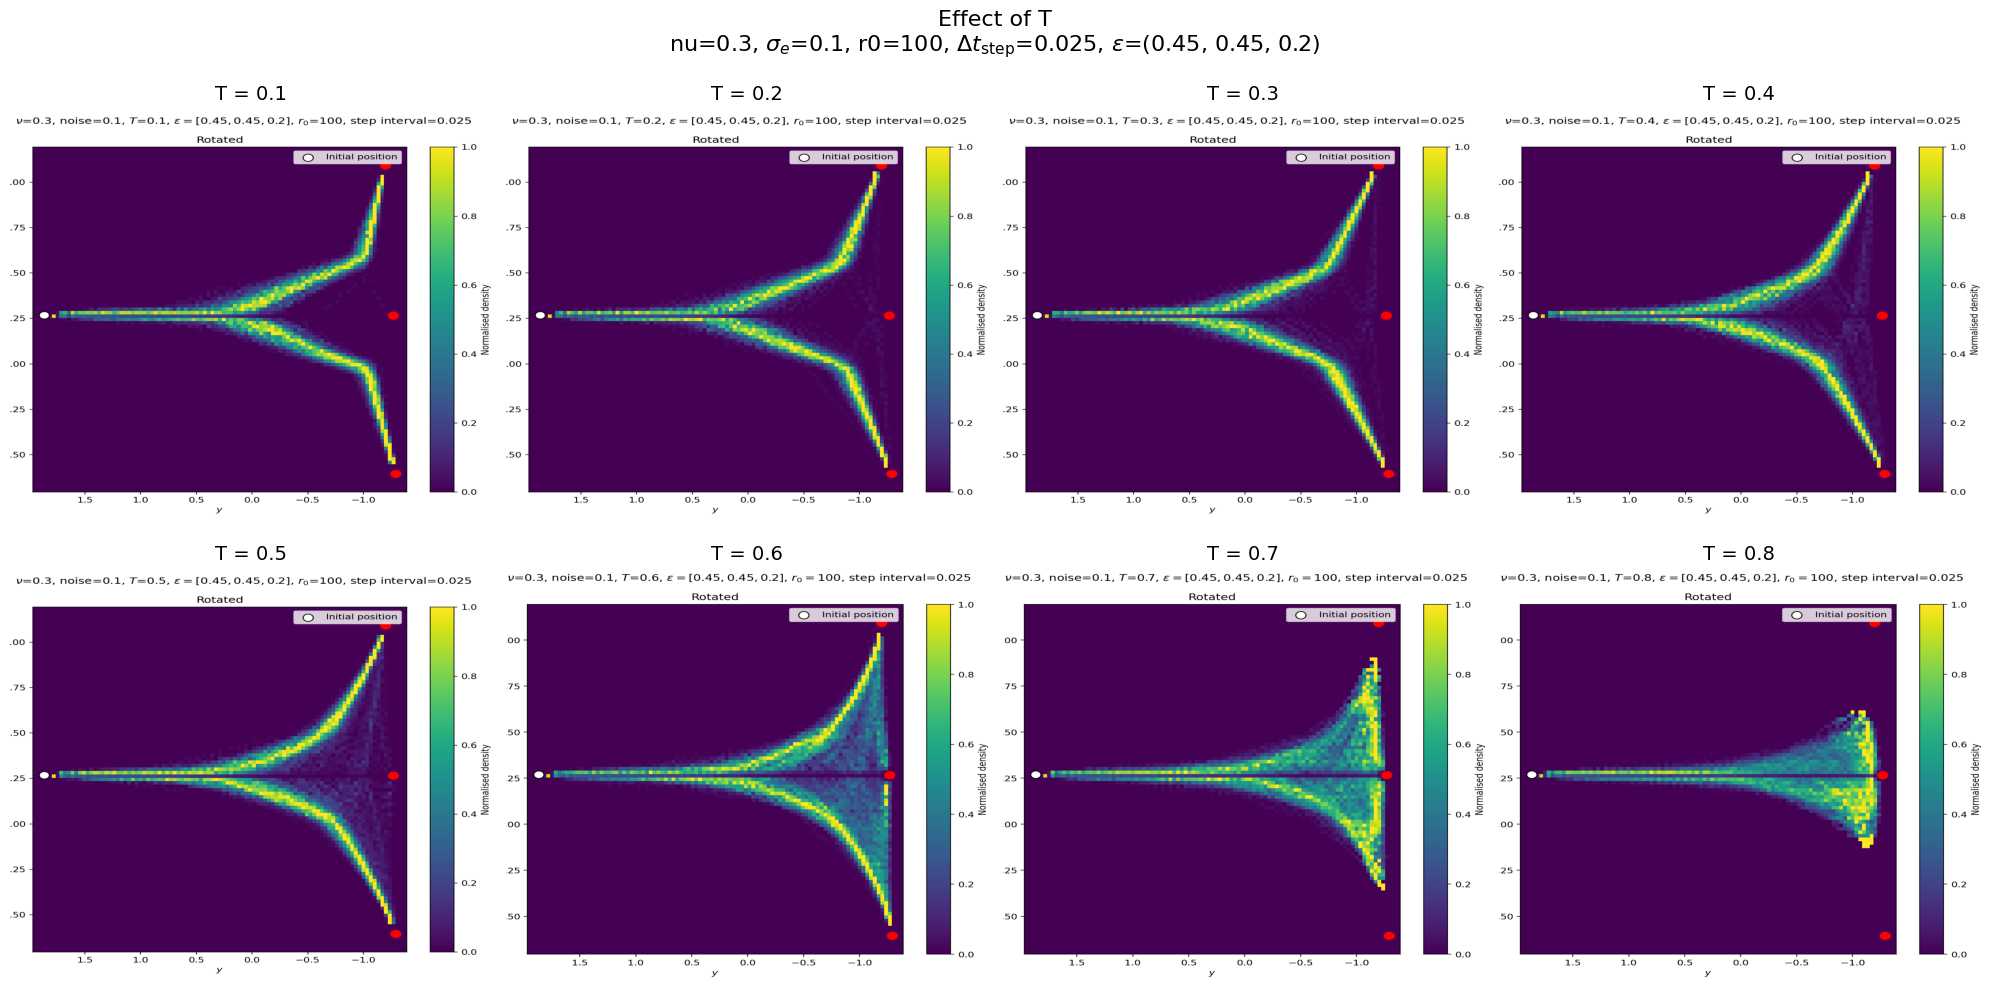


Effect of r0
r0 = 10 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.4_r00010_step0.025.png
r0 = 20 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.4_r00020_step0.025.png
r0 = 30 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.4_r00030_step0.025.png
r0 = 40 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.4_r00040_step0.025.png
r0 = 50 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.4_r00050_step0.025.png
r0 = 60 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.4_r00060_step0.025.png
r0 = 70 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.4_r00070_step0.025.png
r0 = 80 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.4_r080_step0.025.png
r0 = 90 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.4_r090_step0.025.png
r0 = 100 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.4_r0100_step0.025.png
r0 = 110 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.4_r0110_step0.025.png


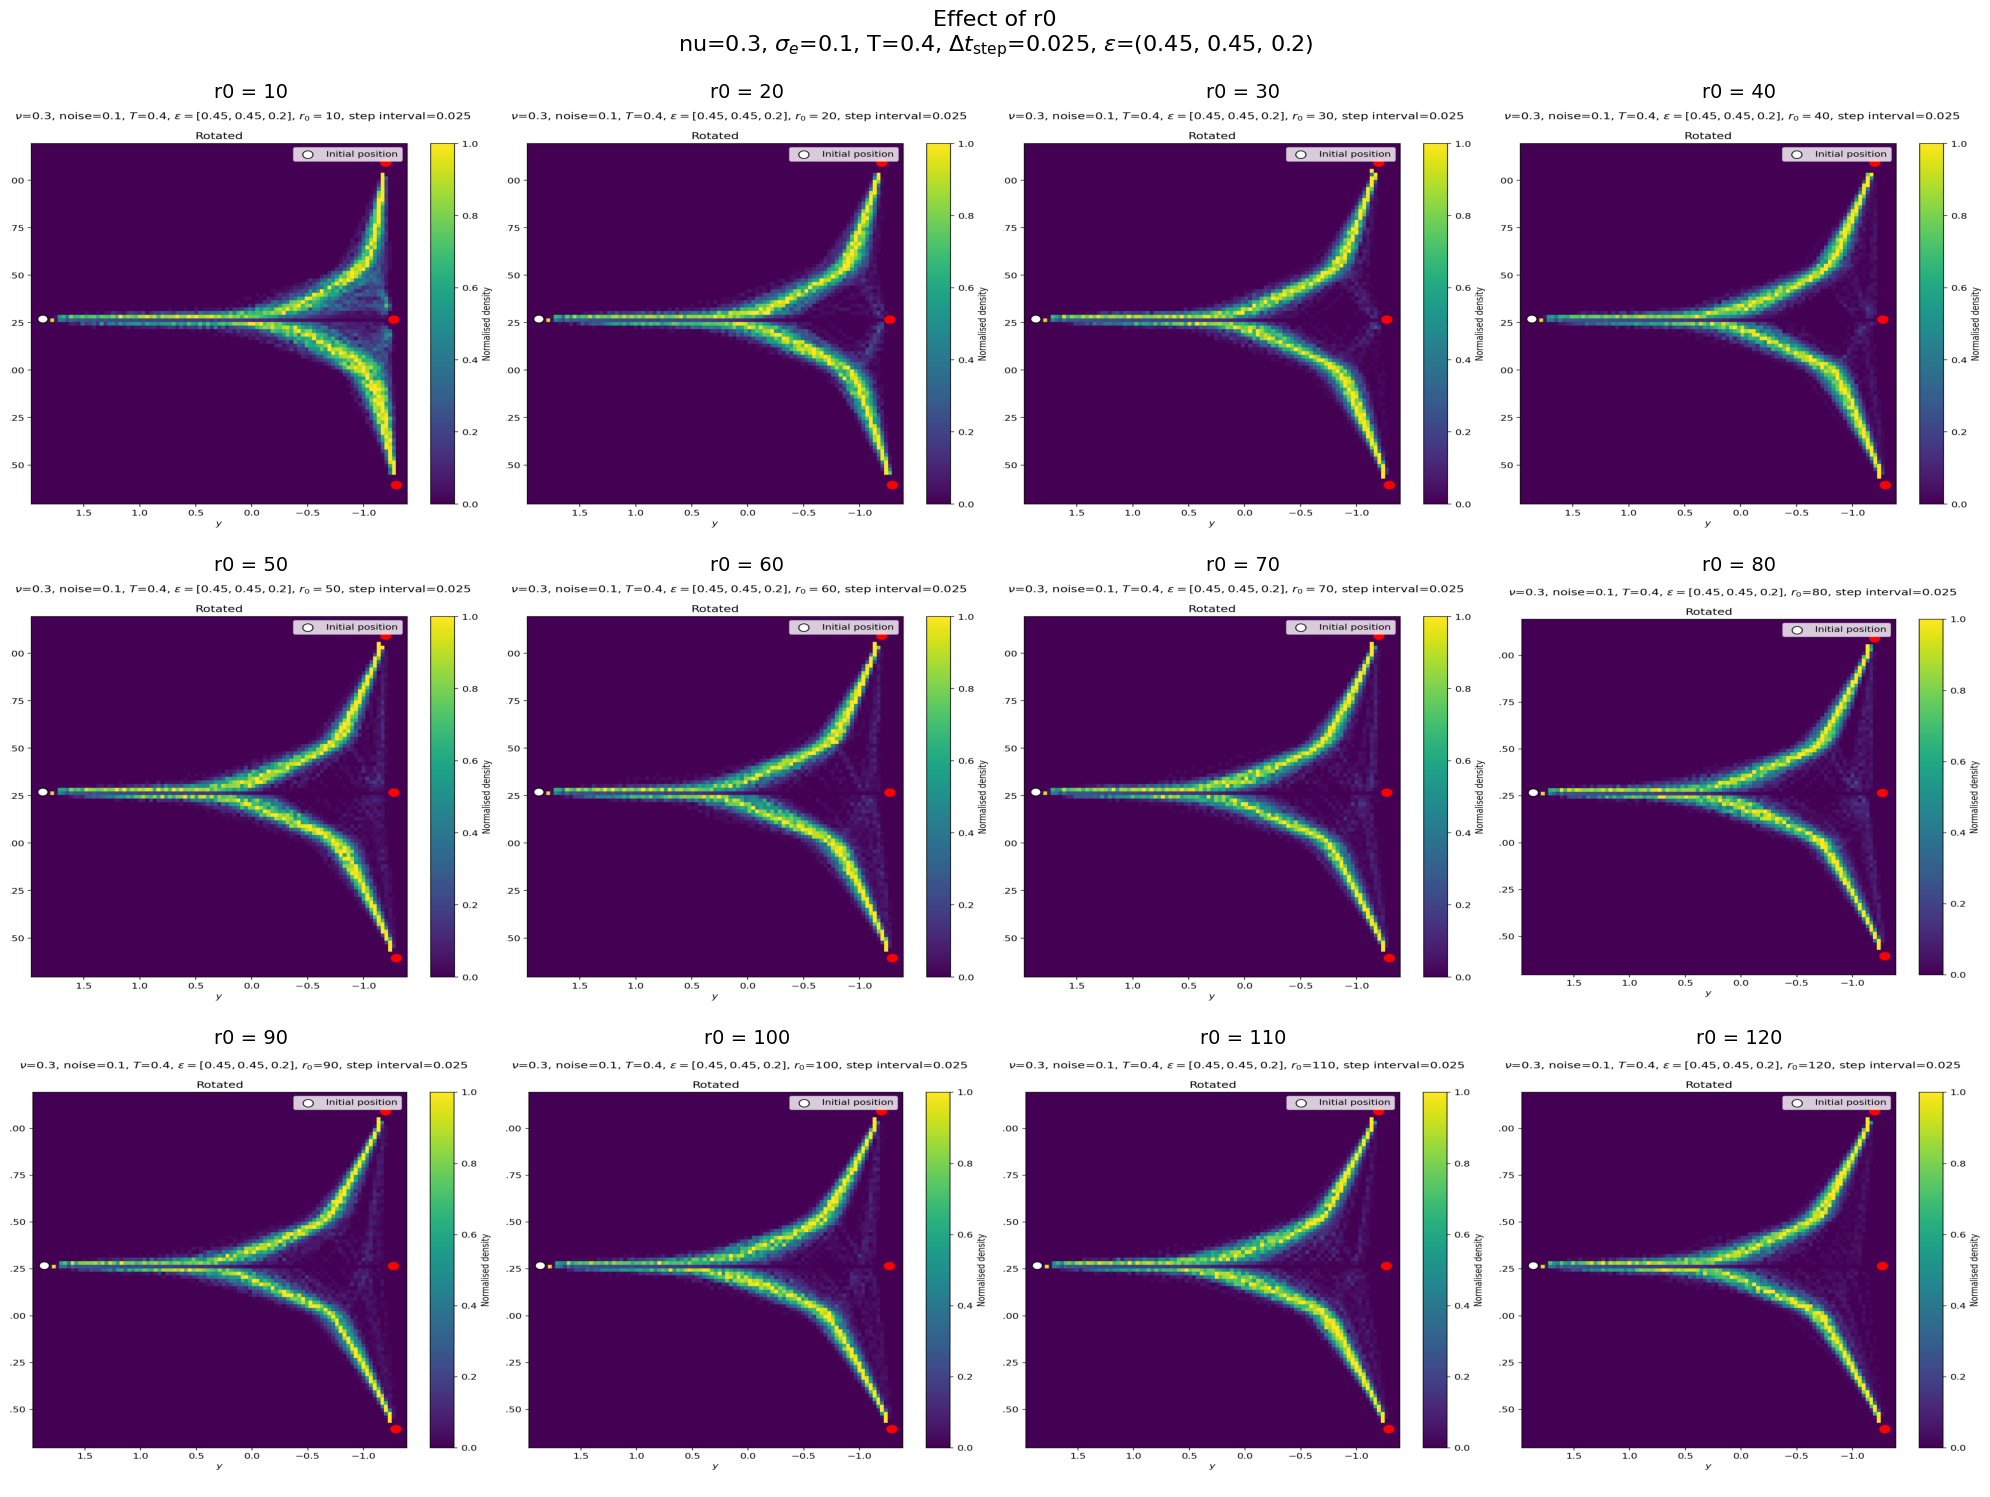


Effect of step_interval
step_interval = 0.025 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.3_r0100_step0.025.png
step_interval = 0.05 -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.3_r0100_step0.05.png


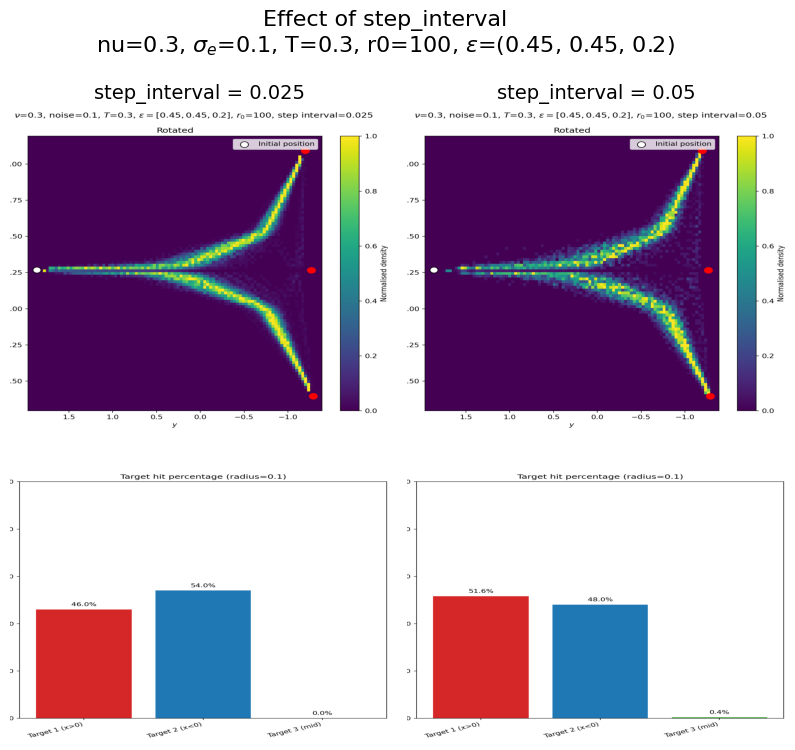


Effect of eps
eps = [0.45, 0.45, 0.05] -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_005\T0.3_r00100_step0.025.png
eps = [0.45, 0.45, 0.10] -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_010\T0.3_r0100_step0.025.png
eps = [0.45, 0.45, 0.20] -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_020\T0.3_r0100_step0.025.png
eps = [0.45, 0.45, 0.30] -> outputs_recovered\nu_0.30\sigma_0.10\eps_045_045_030\T0.3_r0100_step0.025.png


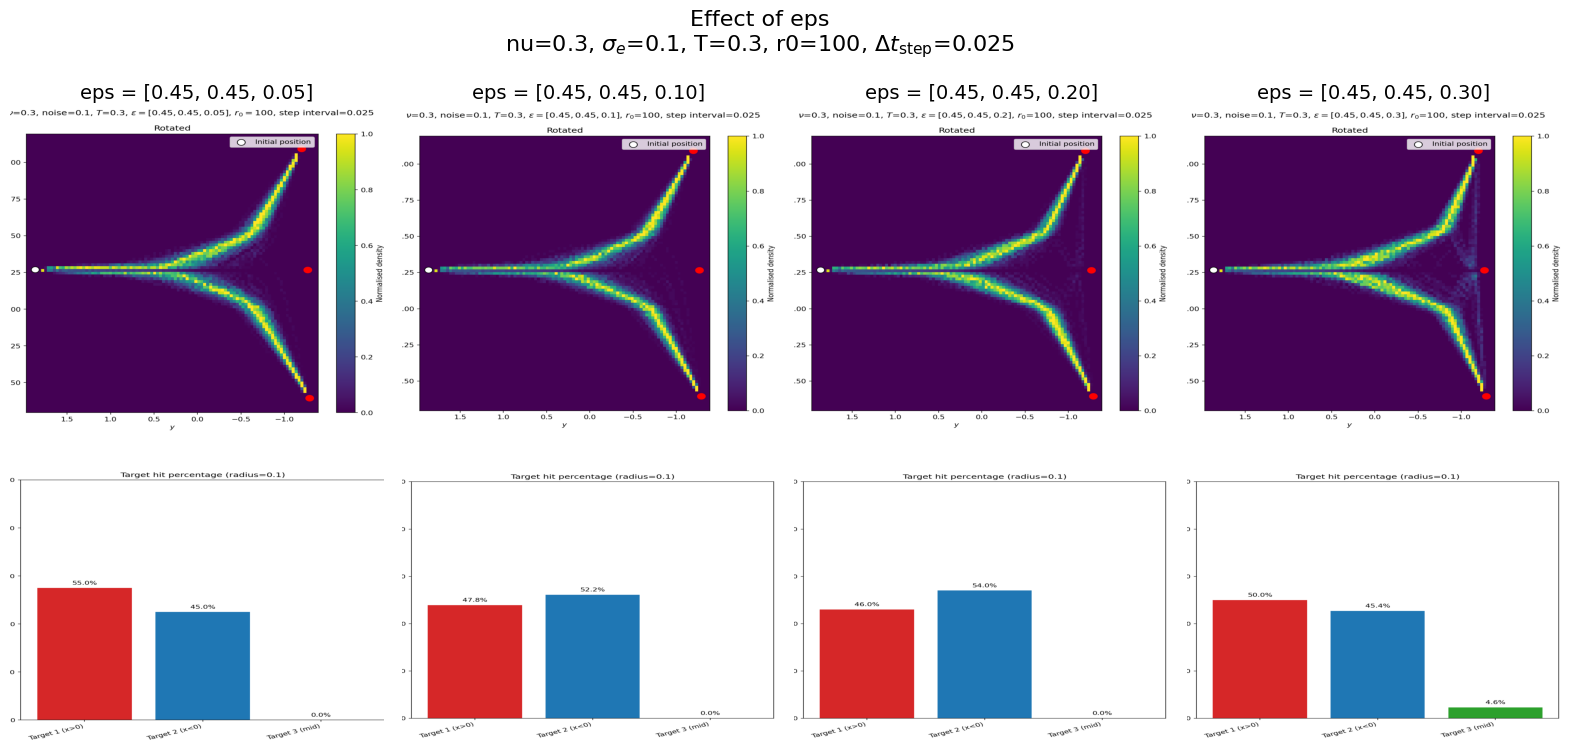


Effect of eps
eps = [0.10, 0.10, 0.45] -> outputs_recovered\nu_0.30\sigma_0.10\eps_010_010_045\T0.3_r00100_step0.025.png
eps = [0.20, 0.20, 0.45] -> outputs_recovered\nu_0.30\sigma_0.10\eps_020_020_045\T0.3_r00100_step0.025.png
eps = [0.30, 0.30, 0.45] -> outputs_recovered\nu_0.30\sigma_0.10\eps_030_030_045\T0.3_r00100_step0.025.png
eps = [0.40, 0.40, 0.45] -> outputs_recovered\nu_0.30\sigma_0.10\eps_040_040_045\T0.3_r00100_step0.025.png


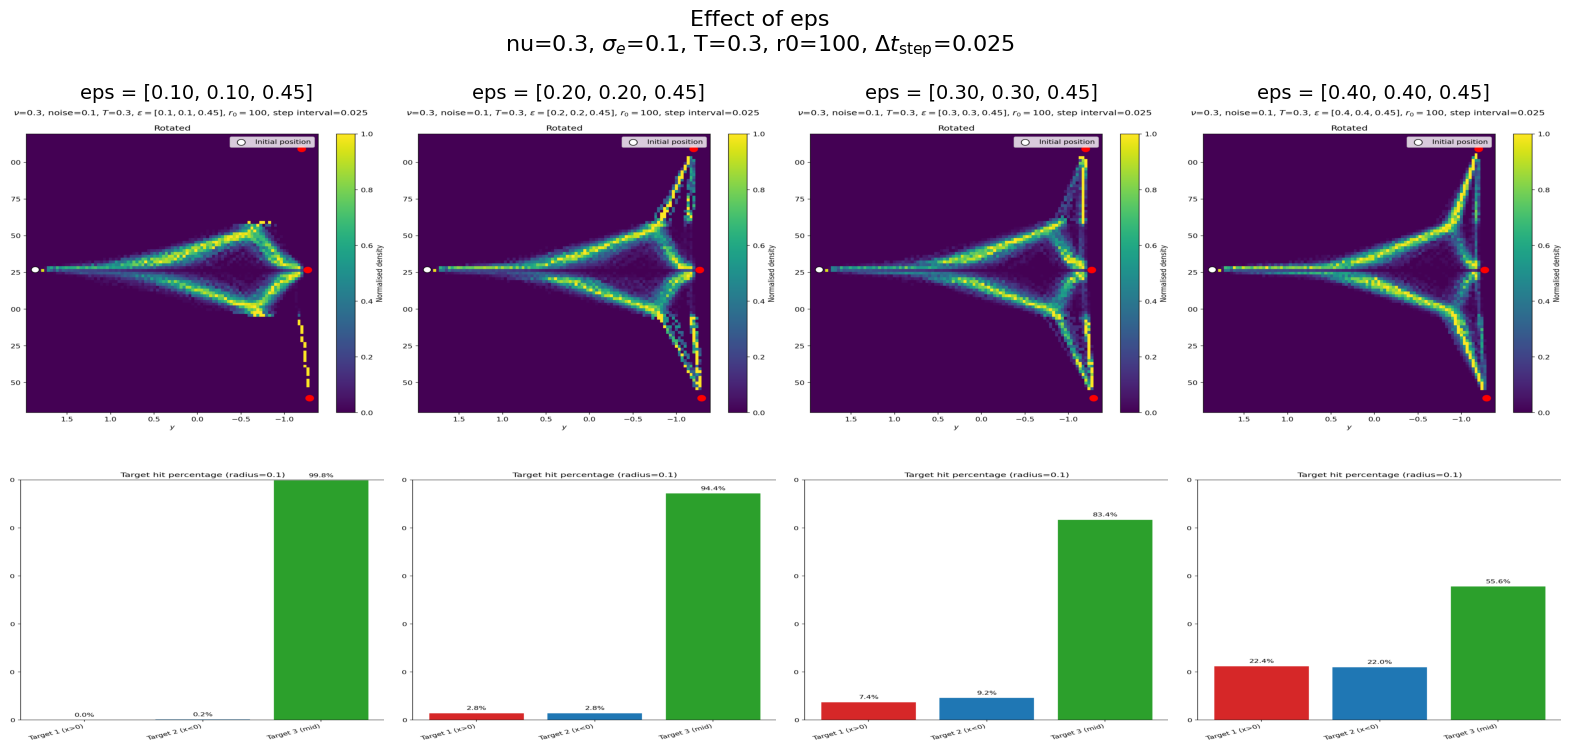

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import ast
import os
from PIL import Image


# ============================================================
# FILES
# ============================================================

SWEEP_CSV = "sweep_results.csv"
RECOVERED_CSV = "recovered_results.csv"

PNG_ROOT = Path(".")


# ============================================================
# LOAD CSVs
# ============================================================

sweep = pd.read_csv(SWEEP_CSV)
recovered = pd.read_csv(RECOVERED_CSV)

sweep["png_path"] = sweep["figure_path"]
recovered["png_path"] = recovered["canonical_png"]

cols = [
    "nu",
    "sigma_e",
    "T",
    "r0",
    "step_interval",
    "eps",
    "png_path",
]

df = pd.concat(
    [
        sweep[cols],
        recovered[cols]
    ],
    ignore_index=True
)


# ============================================================
# EPSILON NORMALIZATION
# ============================================================

def parse_eps(x):

    if isinstance(x, (list, tuple)):
        return tuple(float(v) for v in x)

    return tuple(
        float(v)
        for v in ast.literal_eval(str(x))
    )


df["eps_key"] = df["eps"].apply(parse_eps)


# ============================================================
# REMOVE DUPLICATES
# ============================================================

df = df.drop_duplicates(
    subset=[
        "nu",
        "sigma_e",
        "T",
        "r0",
        "step_interval",
        "eps_key",
    ],
    keep="first"
).reset_index(drop=True)


# ============================================================
# PATH HANDLING
# ============================================================

def get_png_path(row):

    path = str(row["png_path"])

    path = path.replace("\\", os.sep)

    return PNG_ROOT / path


# ============================================================
# FIND PARAMETER COMBINATION
# ============================================================

def find_point(
    nu,
    sigma_e,
    T,
    r0,
    step_interval,
    eps
):

    eps = tuple(float(x) for x in eps)

    mask = (
        df["nu"].eq(nu)
        & df["sigma_e"].eq(sigma_e)
        & df["T"].eq(T)
        & df["r0"].eq(r0)
        & df["step_interval"].eq(step_interval)
        & df["eps_key"].apply(
            lambda x: x == eps
        )
    )

    matches = df.loc[mask]

    if len(matches) == 0:
        return None

    return matches.iloc[0]


# ============================================================
# CROP MIDDLE / ROTATED PANEL
# ============================================================

def crop_middle_panel(image):

    width, height = image.size

    # Approximate rotated panel + its colorbar
    # for the standard 2048 x 744 images.

    left = int(0.355 * width)
    right = int(0.655 * width)

    top = 0
    bottom = height

    return image.crop(
        (
            left,
            top,
            right,
            bottom
        )
    )


# ============================================================
# CROP RIGHT / TARGET-HIT PANEL
# ============================================================

def crop_right_panel(image):

    width, height = image.size

    left = int(0.695 * width)
    right = int(0.995 * width)

    top = int(0.035 * height)
    bottom = int(0.985 * height)

    return image.crop(
        (
            left,
            top,
            right,
            bottom
        )
    )


# ============================================================
# FORMAT PARAMETER VALUE
# ============================================================

def format_value(
    parameter_name,
    value
):

    if parameter_name == "eps":

        return (
            f"[{value[0]:.2f}, "
            f"{value[1]:.2f}, "
            f"{value[2]:.2f}]"
        )

    elif parameter_name == "step_interval":

        return f"{value:g}"

    else:

        return str(value)


# ============================================================
# SHOW PARAMETER SWEEP
# ============================================================

def show_parameter_sweep(
    parameter_name,
    values,
    fixed,
    ncols=3,
    show_target_hist=False,
    panel_width=5,
    panel_height=5
):

    rows = []

    print("\n" + "=" * 70)
    print(f"Effect of {parameter_name}")
    print("=" * 70)


    # ========================================================
    # FIND PARAMETER COMBINATIONS
    # ========================================================

    for value in values:

        params = fixed.copy()
        params[parameter_name] = value

        row = find_point(
            nu=params["nu"],
            sigma_e=params["sigma_e"],
            T=params["T"],
            r0=params["r0"],
            step_interval=params["step_interval"],
            eps=params["eps"],
        )

        value_text = format_value(
            parameter_name,
            value
        )

        if row is None:

            print(
                f"WARNING: No result for "
                f"{parameter_name} = {value_text}"
            )

        else:

            png = get_png_path(row)

            print(
                f"{parameter_name} = "
                f"{value_text} -> {png}"
            )

            rows.append(
                (value, row)
            )


    if not rows:

        print("No images found.")
        return


    # ========================================================
    # FIGURE LAYOUT
    # ========================================================

    n = len(rows)

    nrows = (
        n + ncols - 1
    ) // ncols


    if show_target_hist:

        # ----------------------------------------------------
        # Heatmap on top
        # Histogram directly below it
        # ----------------------------------------------------

        fig, axes = plt.subplots(
            nrows * 2,
            ncols,

            figsize=(
                panel_width * ncols,
                panel_height * nrows * 1.65
            ),

            gridspec_kw={
                "height_ratios":
                    [2.2, 1.8] * nrows,

                "hspace": 0.08,
                "wspace": 0.05,
            }
        )


        # ----------------------------------------------------
        # Force axes to 2D
        # ----------------------------------------------------

        if axes.ndim == 0:

            axes = axes.reshape(
                1,
                1
            )

        elif axes.ndim == 1:

            axes = axes.reshape(
                nrows * 2,
                ncols
            )


        # ====================================================
        # PLOT EACH PARAMETER VALUE
        # ====================================================

        for i, (value, row) in enumerate(rows):

            grid_row = i // ncols
            grid_col = i % ncols

            ax_mid = axes[
                2 * grid_row,
                grid_col
            ]

            ax_hist = axes[
                2 * grid_row + 1,
                grid_col
            ]

            png = get_png_path(row)

            value_text = format_value(
                parameter_name,
                value
            )


            # ------------------------------------------------
            # PNG MISSING
            # ------------------------------------------------

            if not png.exists():

                ax_mid.text(
                    0.5,
                    0.5,
                    "PNG NOT FOUND\n\n"
                    + str(png),
                    ha="center",
                    va="center",
                    wrap=True,
                )

                ax_mid.set_title(
                    f"{parameter_name} = "
                    f"{value_text}",
                    fontsize=14
                )

                ax_mid.axis("off")
                ax_hist.axis("off")

                continue


            # ------------------------------------------------
            # LOAD IMAGE
            # ------------------------------------------------

            with Image.open(png) as img:

                middle = crop_middle_panel(img)
                right = crop_right_panel(img)


            # =================================================
            # ROTATED HEATMAP
            # =================================================

            ax_mid.imshow(
                middle,
                aspect="auto"
            )

            ax_mid.set_title(
                f"{parameter_name} = "
                f"{value_text}",
                fontsize=14,
                pad=4
            )

            ax_mid.axis("off")


            # =================================================
            # TARGET-HIT HISTOGRAM
            # =================================================

            ax_hist.imshow(
                right,
                aspect="auto"
            )

            ax_hist.axis("off")


        # ====================================================
        # HIDE UNUSED GRID CELLS
        # ====================================================

        for i in range(
            len(rows),
            nrows * ncols
        ):

            grid_row = i // ncols
            grid_col = i % ncols

            axes[
                2 * grid_row,
                grid_col
            ].axis("off")

            axes[
                2 * grid_row + 1,
                grid_col
            ].axis("off")


    # ========================================================
    # WITHOUT TARGET HISTOGRAM
    # ========================================================

    else:

        fig, axes = plt.subplots(
            nrows,
            ncols,

            figsize=(
                panel_width * ncols,
                panel_height * nrows
            )
        )


        # ----------------------------------------------------
        # Ensure axes is iterable
        # ----------------------------------------------------

        if hasattr(
            axes,
            "flatten"
        ):

            axes = axes.flatten()

        else:

            axes = [axes]


        # ====================================================
        # PLOT ROTATED HEATMAPS
        # ====================================================

        for ax, (value, row) in zip(
            axes,
            rows
        ):

            png = get_png_path(row)

            value_text = format_value(
                parameter_name,
                value
            )

            if not png.exists():

                ax.text(
                    0.5,
                    0.5,
                    "PNG NOT FOUND\n\n"
                    + str(png),
                    ha="center",
                    va="center",
                    wrap=True,
                )

                ax.set_title(
                    f"{parameter_name} = "
                    f"{value_text}",
                    fontsize=14
                )

            else:

                with Image.open(png) as img:

                    middle = crop_middle_panel(img)

                ax.imshow(
                    middle,
                    aspect="auto"
                )

                ax.set_title(
                    f"{parameter_name} = "
                    f"{value_text}",
                    fontsize=14
                )

            ax.axis("off")


        # ----------------------------------------------------
        # Hide unused axes
        # ----------------------------------------------------

        for ax in axes[len(rows):]:

            ax.axis("off")


    # ========================================================
    # OVERALL TITLE
    # ========================================================

    fixed_text = []

    for key, value in fixed.items():

        if key == parameter_name:
            continue

        if key == "eps":

            fixed_text.append(
                r"$\epsilon$="
                + str(value)
            )

        elif key == "step_interval":

            fixed_text.append(
                r"$\Delta t_{\rm step}$="
                + str(value)
            )

        elif key == "sigma_e":

            fixed_text.append(
                r"$\sigma_e$="
                + str(value)
            )

        else:

            fixed_text.append(
                f"{key}={value}"
            )


    fig.suptitle(
        f"Effect of {parameter_name}\n"
        + ", ".join(fixed_text),

        fontsize=16,
        y=0.995
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# COMMON BASELINE
# ============================================================

BASELINE = {

    "nu": 0.30,

    "sigma_e": 0.10,

    "T": 0.30,

    "r0": 100,

    "step_interval": 0.025,

    "eps": (
        0.45,
        0.45,
        0.20
    ),
}


# ============================================================
# 1. EFFECT OF nu
# ============================================================

show_parameter_sweep(

    parameter_name="nu",

    values=[
        0.20,
        0.25,
        0.30,
        0.35,
        0.40,
        0.45,
    ],

    fixed=BASELINE,

    ncols=3,

    show_target_hist=False,
)


# ============================================================
# 2. EFFECT OF sigma_e
#
# SPLIT INTO TWO FIGURES
#
# Each figure:
#   4 parameter values
#   × 2 panels/value
#   = 8 panels
# ============================================================


# ------------------------------------------------------------
# sigma_e : first 4 values
# ------------------------------------------------------------

show_parameter_sweep(

    parameter_name="sigma_e",

    values=[
        0.10,
        0.20,
        0.25,
        0.35,
    ],

    fixed=BASELINE,

    ncols=4,

    show_target_hist=True,
)


# ------------------------------------------------------------
# sigma_e : last 4 values
# ------------------------------------------------------------

show_parameter_sweep(

    parameter_name="sigma_e",

    values=[
        0.50,
        0.65,
        0.80,
        1.00,
    ],

    fixed=BASELINE,

    ncols=4,

    show_target_hist=True,
)

# ============================================================
# 3. EFFECT OF T
#
# TOTAL = 8 VALUES
#
# Newly simulated:
#   0.6, 0.7, 0.8
#
# IMPORTANT:
# nu = 0.30
# ============================================================

T_BASELINE = {

    "nu": 0.30,

    "sigma_e": 0.10,

    "T": 0.30,

    "r0": 100,

    "step_interval": 0.025,

    "eps": (
        0.45,
        0.45,
        0.20
    ),
}


show_parameter_sweep(

    parameter_name="T",

    values=[
        0.10,
        0.20,
        0.30,
        0.40,
        0.50,
        0.60,
        0.70,
        0.80,
    ],

    fixed=T_BASELINE,

    ncols=4,

    show_target_hist=False,
)


# ============================================================
# 4. EFFECT OF r0
#
# TOTAL = 12 VALUES
#
# New low-r0 simulations:
#   10,20,30,...,80
#
# Existing:
#   90,100,110,120
#
# T = 0.4
#
# No special 10/50 comparison anymore.
# ============================================================

R0_BASELINE = {

    "nu": 0.30,

    "sigma_e": 0.10,

    "T": 0.40,

    "r0": 100,

    "step_interval": 0.025,

    "eps": (
        0.45,
        0.45,
        0.20
    ),
}


show_parameter_sweep(

    parameter_name="r0",

    values=[
        10,
        20,
        30,
        40,
        50,
        60,
        70,
        80,
        90,
        100,
        110,
        120,
    ],

    fixed=R0_BASELINE,

    ncols=4,

    show_target_hist=False,
)


# ============================================================
# 5. EFFECT OF STEP INTERVAL
#
# TARGET-HIT HISTOGRAM INCLUDED
# ============================================================

show_parameter_sweep(

    parameter_name="step_interval",

    values=[
        0.025,
        0.05,
    ],

    fixed=BASELINE,

    ncols=2,

    show_target_hist=True,
)


# ============================================================
# 6. EFFECT OF EPSILON
#
# SPLIT INTO TWO FIGURES
#
# Each figure:
#   4 parameter values
#   × 2 panels/value
#   = 8 panels
#
# eps[0] = eps[1] in every case.
# ============================================================


# ------------------------------------------------------------
# EPSILON : first 4 values
#
# Vary bias toward Target 3 while keeping
# Target 1 and Target 2 symmetric.
# ------------------------------------------------------------

show_parameter_sweep(

    parameter_name="eps",

    values=[

        (
            0.45,
            0.45,
            0.05
        ),

        (
            0.45,
            0.45,
            0.10
        ),

        (
            0.45,
            0.45,
            0.20
        ),

        (
            0.45,
            0.45,
            0.30
        ),
    ],

    fixed=BASELINE,

    ncols=4,

    show_target_hist=True,
)


# ------------------------------------------------------------
# EPSILON : last 4 values
#
# Target 1 and Target 2 remain equally biased.
# Target 3 fixed at 0.45.
# ------------------------------------------------------------

show_parameter_sweep(

    parameter_name="eps",

    values=[

        (
            0.10,
            0.10,
            0.45
        ),

        (
            0.20,
            0.20,
            0.45
        ),

        (
            0.30,
            0.30,
            0.45
        ),

        (
            0.40,
            0.40,
            0.45
        ),
    ],

    fixed=BASELINE,

    ncols=4,

    show_target_hist=True,
)

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import ast
import os
import time


# ============================================================
# CONFIGURATION
# ============================================================

OUTPUT_ROOT = Path("outputs_recovered")
CSV_PATH = Path("recovered_results.csv")


# ============================================================
# BASELINE
# ============================================================

BASELINE = {
    "nu": 0.30,
    "sigma_e": 0.10,
    "T": 0.30,
    "r0": 100,
    "step_interval": 0.025,
    "eps": [0.45, 0.45, 0.20],
}


# ============================================================
# NEW sigma_e VALUES
#
# Already available:
#   0.10, 0.20, 0.25
#
# New:
#   0.35, 0.50, 0.65, 0.80, 1.00
# ============================================================

SIGMA_NEW = [
    0.35,
    0.50,
    0.65,
    0.80,
    1.00,
]


# ============================================================
# NEW EPSILON VALUES
#
# Existing:
#
#   (0.45, 0.45, 0.10)
#   (0.45, 0.45, 0.20)
#   (0.45, 0.45, 0.30)
#
# New:
#
#   (0.10, 0.10, 0.45)
#   (0.20, 0.20, 0.45)
#   (0.30, 0.30, 0.45)
#   (0.40, 0.40, 0.45)
#   (0.45, 0.45, 0.05)
#
# In all cases:
#       eps[0] == eps[1]
#
# so Targets 1 and 2 remain symmetric.
# ============================================================

EPS_NEW = [
    [0.10, 0.10, 0.45],
    [0.20, 0.20, 0.45],
    [0.30, 0.30, 0.45],
    [0.40, 0.40, 0.45],
    [0.45, 0.45, 0.05],
]


# ============================================================
# SIMULATION PARAMETERS
#
# Same as your existing simulation code.
# ============================================================

x0 = [0.269, 1.868]

N = 60
k = 3
v0 = 3.5
eta = 0

num_trajs = 500
t_max = 5.0
n_jobs = 16


target_positions = np.array([
    [1.093, -1.196],
    [-0.605, -1.289],
    [0.267, -1.267]
])


# ============================================================
# TARGET DEFINITIONS
# ============================================================

targets = {
    "Target 1 (x>0)": (1.093, -1.196),
    "Target 2 (x<0)": (-0.605, -1.289),
    "Target 3 (mid)": (0.267, -1.267),
}

hit_radius = 0.1


# ============================================================
# EPSILON FOLDER NAME
# ============================================================

def eps_folder(eps):

    return (
        f"eps_"
        f"{int(round(eps[0] * 100)):03d}_"
        f"{int(round(eps[1] * 100)):03d}_"
        f"{int(round(eps[2] * 100)):03d}"
    )


# ============================================================
# OUTPUT PATHS
#
# Same structure as your existing recovered outputs:
#
# outputs_recovered/
#   nu_0.30/
#       sigma_0.35/
#           eps_010_010_045/
#               T0.3_r00100_step0.025.png
#               T0.3_r00100_step0.025.npy
# ============================================================

def get_output_paths(
    nu,
    sigma_e,
    T,
    r0,
    step_interval,
    eps
):

    folder = (
        OUTPUT_ROOT
        / f"nu_{nu:.2f}"
        / f"sigma_{sigma_e:.2f}"
        / eps_folder(eps)
    )

    folder.mkdir(
        parents=True,
        exist_ok=True
    )

    filename = (
        f"T{T:g}_"
        f"r0{int(r0):04d}_"
        f"step{step_interval:g}"
    )

    png_path = folder / f"{filename}.png"
    npy_path = folder / f"{filename}.npy"

    return png_path, npy_path


# ============================================================
# HIT ANALYSIS
# ============================================================

def calculate_hit_percentages(trajs):

    hit_counts = {
        name: 0
        for name in targets
    }

    no_hit_count = 0

    for traj in trajs:

        traj = np.asarray(traj)

        first_hit_name = None
        first_hit_index = np.inf

        for name, (tx, ty) in targets.items():

            d = np.sqrt(
                (traj[:, 0] - tx) ** 2
                +
                (traj[:, 1] - ty) ** 2
            )

            idx = np.where(
                d <= hit_radius
            )[0]

            if (
                len(idx) > 0
                and idx[0] < first_hit_index
            ):

                first_hit_index = idx[0]
                first_hit_name = name

        if first_hit_name is not None:

            hit_counts[first_hit_name] += 1

        else:

            no_hit_count += 1


    n_traj = len(trajs)

    hit_pcts = {
        name:
        100 * count / n_traj
        for name, count in hit_counts.items()
    }

    no_hit_pct = (
        100 * no_hit_count / n_traj
    )

    return (
        hit_counts,
        hit_pcts,
        no_hit_count,
        no_hit_pct
    )


# ============================================================
# MAKE SIMULATION FIGURE
# ============================================================

def make_figure(
    trajs,
    x0,
    nu,
    sigma_e,
    T,
    r0,
    eps,
    step_interval,
    png_path
):

    bins = 100

    (
        hit_counts,
        hit_pcts,
        no_hit_count,
        no_hit_pct
    ) = calculate_hit_percentages(trajs)


    # --------------------------------------------------------
    # Spatial range
    # --------------------------------------------------------

    x_edges = np.linspace(
        min(
            x0[0],
            1.093,
            -0.605,
            0.267
        ) - 0.1,

        max(
            x0[0],
            1.093,
            -0.605,
            0.267
        ) + 0.1,

        bins
    )

    y_edges = np.linspace(
        min(
            x0[1],
            -1.196,
            -1.289,
            -1.267
        ) - 0.1,

        max(
            x0[1],
            -1.196,
            -1.289,
            -1.267
        ) + 0.1,

        bins
    )


    # --------------------------------------------------------
    # Count trajectories passing through bins
    # --------------------------------------------------------

    H = np.zeros(
        (
            bins - 1,
            bins - 1
        )
    )

    for traj in trajs:

        traj = np.asarray(traj)

        h, _, _ = np.histogram2d(
            traj[:, 0],
            traj[:, 1],
            bins=[
                x_edges,
                y_edges
            ]
        )

        H += (
            h > 0
        ).astype(float)


    # --------------------------------------------------------
    # Original orientation
    # --------------------------------------------------------

    H_orig = H.T

    col_max = H_orig.max(
        axis=0,
        keepdims=True
    )

    col_max[
        col_max == 0
    ] = 1

    H_orig = H_orig / col_max


    # --------------------------------------------------------
    # Rotated orientation
    # --------------------------------------------------------

    H_rot = H.copy()

    row_max = H_rot.max(
        axis=1,
        keepdims=True
    )

    row_max[
        row_max == 0
    ] = 1

    H_rot = H_rot / row_max


    # ========================================================
    # FIGURE
    # ========================================================

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(22, 8)
    )


    # ========================================================
    # ORIGINAL
    # ========================================================

    ax = axes[0]

    im0 = ax.imshow(
        H_orig,
        origin="lower",
        aspect="auto",
        extent=[
            x_edges[0],
            x_edges[-1],
            y_edges[0],
            y_edges[-1]
        ],
        cmap="viridis",
        vmin=0,
        vmax=1
    )

    for tx, ty in target_positions:

        ax.scatter(
            tx,
            ty,
            s=100,
            color="red"
        )

    ax.scatter(
        x0[0],
        x0[1],
        s=100,
        color="white",
        edgecolor="black",
        label="Initial position"
    )

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.set_title("Original")
    ax.legend()

    fig.colorbar(
        im0,
        ax=ax,
        label="Normalised density"
    )


    # ========================================================
    # ROTATED
    # ========================================================

    ax = axes[1]

    im1 = ax.imshow(
        H_rot,
        origin="lower",
        aspect="auto",
        extent=[
            y_edges[0],
            y_edges[-1],
            x_edges[0],
            x_edges[-1]
        ],
        cmap="viridis",
        vmin=0,
        vmax=1
    )

    ax.scatter(
        -1.196,
        1.093,
        s=100,
        color="red"
    )

    ax.scatter(
        -1.289,
        -0.605,
        s=100,
        color="red"
    )

    ax.scatter(
        -1.267,
        0.267,
        s=100,
        color="red"
    )

    ax.scatter(
        x0[1],
        x0[0],
        s=100,
        color="white",
        edgecolor="black",
        label="Initial position"
    )

    ax.invert_xaxis()

    ax.set_xlabel("$y$")
    ax.set_ylabel("$x$")
    ax.set_title("Rotated")
    ax.legend()

    fig.colorbar(
        im1,
        ax=ax,
        label="Normalised density"
    )


    # ========================================================
    # TARGET HIT PERCENTAGES
    # ========================================================

    ax = axes[2]

    labels = list(
        targets.keys()
    )

    pcts = [
        hit_pcts[name]
        for name in labels
    ]

    bars = ax.bar(
        labels,
        pcts,
        color=[
            "tab:red",
            "tab:blue",
            "tab:green"
        ]
    )

    ax.set_ylabel(
        "% of trajectories"
    )

    ax.set_title(
        f"Target hit percentage "
        f"(radius={hit_radius})"
    )

    ax.set_ylim(
        0,
        100
    )

    for bar, pct in zip(
        bars,
        pcts
    ):

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,

            bar.get_height()
            + 1,

            f"{pct:.1f}%",

            ha="center",
            va="bottom"
        )

    plt.setp(
        ax.get_xticklabels(),
        rotation=20,
        ha="right"
    )


    # ========================================================
    # SUPERTITLE
    # ========================================================

    fig.suptitle(
        fr"$\nu$={nu}, "
        fr"noise={sigma_e}, "
        fr"$T$={T}, "
        fr"$\epsilon={eps}$, "
        fr"$r_0={r0}$, "
        fr"step interval={step_interval}"
    )

    plt.tight_layout()


    # ========================================================
    # SAVE PNG
    # ========================================================

    fig.savefig(
        png_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close(fig)

    return (
        hit_counts,
        hit_pcts,
        no_hit_count,
        no_hit_pct
    )


# ============================================================
# CONSTRUCT NEW SIMULATION LIST
# ============================================================

new_simulations = []


# ============================================================
# NEW sigma_e SIMULATIONS
# ============================================================

for sigma_e in SIGMA_NEW:

    new_simulations.append({

        "nu": BASELINE["nu"],

        "sigma_e": sigma_e,

        "T": BASELINE["T"],

        "r0": BASELINE["r0"],

        "step_interval":
            BASELINE["step_interval"],

        "eps":
            BASELINE["eps"].copy(),

        "sweep_type":
            "sigma_e",
    })


# ============================================================
# NEW epsilon SIMULATIONS
# ============================================================

for eps in EPS_NEW:

    new_simulations.append({

        "nu": BASELINE["nu"],

        "sigma_e":
            BASELINE["sigma_e"],

        "T": BASELINE["T"],

        "r0": BASELINE["r0"],

        "step_interval":
            BASELINE["step_interval"],

        "eps":
            eps.copy(),

        "sweep_type":
            "eps",
    })


# ============================================================
# SUMMARY
# ============================================================

print(
    f"Total new simulations: "
    f"{len(new_simulations)}"
)

print()
print("New sigma_e values:")
print(SIGMA_NEW)

print()
print("New epsilon values:")
for eps in EPS_NEW:
    print(eps)


# ============================================================
# RUN SIMULATIONS
# ============================================================

results_for_csv = []


for i, params in enumerate(
    new_simulations,
    start=1
):

    nu = params["nu"]
    sigma_e = params["sigma_e"]
    T = params["T"]
    r0 = params["r0"]
    step_interval = params["step_interval"]
    eps = params["eps"]


    print()
    print("=" * 80)

    print(
        f"[{i}/{len(new_simulations)}]"
    )

    print(
        f"nu={nu}, "
        f"sigma_e={sigma_e}, "
        f"T={T}, "
        f"r0={r0}, "
        f"step={step_interval}, "
        f"eps={eps}"
    )


    # --------------------------------------------------------
    # Output paths
    # --------------------------------------------------------

    png_path, npy_path = get_output_paths(
        nu=nu,
        sigma_e=sigma_e,
        T=T,
        r0=r0,
        step_interval=step_interval,
        eps=eps
    )

    print(
        f"PNG : {png_path}"
    )

    print(
        f"NPY : {npy_path}"
    )


    # --------------------------------------------------------
    # Safety check
    #
    # If both files already exist, do NOT rerun the expensive
    # simulation.
    # --------------------------------------------------------

    if (
        png_path.exists()
        and npy_path.exists()
    ):

        print(
            "Files already exist."
        )

        print(
            "Skipping simulation."
        )

        # ----------------------------------------------------
        # Load trajectories and reconstruct CSV information.
        # ----------------------------------------------------

        try:

            trajs = np.load(
                npy_path,
                allow_pickle=True
            )

            (
                hit_counts,
                hit_pcts,
                no_hit_count,
                no_hit_pct
            ) = calculate_hit_percentages(
                trajs
            )

            elapsed = 0.0

        except Exception as e:

            print(
                "Could not load existing "
                f"trajectory data: {e}"
            )

            print(
                "Will rerun simulation."
            )

            trajs = None

    else:

        trajs = None


    # --------------------------------------------------------
    # RUN if necessary
    # --------------------------------------------------------

    if trajs is None:

        start_time = time.time()

        trajs = run_simul_k3(

            x0=x0,

            nu=nu,

            sigma_e=sigma_e,

            T=T,

            num_trajs=num_trajs,

            N=N,

            v0=v0,

            k=k,

            r0=r0,

            eta=eta,

            eps=eps,

            target_positions=
                target_positions,

            t_max=t_max,

            step_interv=
                step_interval,

            n_jobs=n_jobs
        )

        elapsed = (
            time.time()
            - start_time
        )

        print(
            f"Simulation completed "
            f"in {elapsed:.2f} s"
        )


        # ----------------------------------------------------
        # Save trajectory data
        # ----------------------------------------------------

        np.save(
            npy_path,
            np.asarray(
                trajs,
                dtype=object
            ),
            allow_pickle=True
        )

        print(
            "Trajectory data saved."
        )


        # ----------------------------------------------------
        # Create figure
        # ----------------------------------------------------

        (
            hit_counts,
            hit_pcts,
            no_hit_count,
            no_hit_pct
        ) = make_figure(

            trajs=trajs,

            x0=x0,

            nu=nu,

            sigma_e=sigma_e,

            T=T,

            r0=r0,

            eps=eps,

            step_interval=
                step_interval,

            png_path=png_path
        )

        print(
            "Figure saved."
        )

    else:

        # ----------------------------------------------------
        # If files existed, make sure the figure exists.
        # ----------------------------------------------------

        if not png_path.exists():

            (
                hit_counts,
                hit_pcts,
                no_hit_count,
                no_hit_pct
            ) = make_figure(

                trajs=trajs,

                x0=x0,

                nu=nu,

                sigma_e=sigma_e,

                T=T,

                r0=r0,

                eps=eps,

                step_interval=
                    step_interval,

                png_path=png_path
            )

            print(
                "Figure regenerated."
            )


    # --------------------------------------------------------
    # Print statistics
    # --------------------------------------------------------

    print(
        f"Hit percentages: "
        f"{hit_pcts}"
    )

    print(
        f"No hit: "
        f"{no_hit_pct:.2f}%"
    )


    # --------------------------------------------------------
    # Save result for CSV
    # --------------------------------------------------------

    results_for_csv.append({

        "nu":
            nu,

        "sigma_e":
            sigma_e,

        "T":
            T,

        "r0":
            r0,

        "step_interval":
            step_interval,

        "eps":
            str(eps),

        "canonical_png":
            str(png_path).replace(
                "/",
                "\\"
            ),

        "canonical_data":
            str(npy_path).replace(
                "/",
                "\\"
            ),

        "target_1_hit_pct":
            hit_pcts[
                "Target 1 (x>0)"
            ],

        "target_2_hit_pct":
            hit_pcts[
                "Target 2 (x<0)"
            ],

        "target_3_hit_pct":
            hit_pcts[
                "Target 3 (mid)"
            ],

        "no_hit_pct":
            no_hit_pct,

        "num_trajectories":
            len(trajs),

        "sweep_type":
            params["sweep_type"],
    })


# ============================================================
# UPDATE recovered_results.csv
# ============================================================

print()
print("=" * 80)
print("UPDATING recovered_results.csv")
print("=" * 80)


new_df = pd.DataFrame(
    results_for_csv
)


# ------------------------------------------------------------
# Load existing CSV
# ------------------------------------------------------------

if CSV_PATH.exists():

    old_df = pd.read_csv(
        CSV_PATH
    )

    print(
        f"Existing CSV rows: "
        f"{len(old_df)}"
    )

else:

    print(
        "WARNING: recovered_results.csv "
        "does not exist."
    )

    old_df = pd.DataFrame()


# ============================================================
# ENSURE NEW COLUMNS EXIST
# ============================================================

for col in new_df.columns:

    if col not in old_df.columns:

        old_df[col] = np.nan


# ============================================================
# NORMALIZE EPSILON FOR DUPLICATE CHECKING
# ============================================================

def normalize_eps(x):

    try:

        value = ast.literal_eval(
            str(x)
        )

        return tuple(
            round(float(v), 10)
            for v in value
        )

    except Exception:

        return str(x)


if len(old_df) > 0:

    old_df["_eps_key"] = (
        old_df["eps"]
        .apply(normalize_eps)
    )

else:

    old_df["_eps_key"] = pd.Series(
        dtype=object
    )


new_df["_eps_key"] = (
    new_df["eps"]
    .apply(normalize_eps)
)


# ============================================================
# CREATE UNIQUE PARAMETER KEYS
# ============================================================

def parameter_key(row):

    return (
        round(float(row["nu"]), 10),

        round(
            float(row["sigma_e"]),
            10
        ),

        round(
            float(row["T"]),
            10
        ),

        round(
            float(row["r0"]),
            10
        ),

        round(
            float(row["step_interval"]),
            10
        ),

        row["_eps_key"],
    )


existing_keys = set()

for _, row in old_df.iterrows():

    try:

        existing_keys.add(
            parameter_key(row)
        )

    except Exception:

        pass


# ============================================================
# DETERMINE WHAT TO APPEND
# ============================================================

rows_to_add = []


for _, row in new_df.iterrows():

    key = parameter_key(row)

    if key in existing_keys:

        print(
            "Already present — not adding:"
        )

        print(
            f"  nu={row['nu']}, "
            f"sigma_e={row['sigma_e']}, "
            f"T={row['T']}, "
            f"r0={row['r0']}, "
            f"step={row['step_interval']}, "
            f"eps={row['eps']}"
        )

    else:

        rows_to_add.append(
            row
        )

        existing_keys.add(
            key
        )


# ============================================================
# APPEND
# ============================================================

if rows_to_add:

    add_df = pd.DataFrame(
        rows_to_add
    )

    final_df = pd.concat(
        [
            old_df,
            add_df
        ],
        ignore_index=True
    )

else:

    final_df = old_df.copy()


# ============================================================
# REMOVE INTERNAL COLUMN
# ============================================================

if "_eps_key" in final_df.columns:

    final_df = final_df.drop(
        columns=["_eps_key"]
    )


# ============================================================
# SAVE CSV
# ============================================================

final_df.to_csv(
    CSV_PATH,
    index=False
)


# ============================================================
# FINAL REPORT
# ============================================================

print()
print(
    f"New rows added: "
    f"{len(rows_to_add)}"
)

print(
    f"Total rows in CSV: "
    f"{len(final_df)}"
)

print(
    f"CSV saved to: "
    f"{CSV_PATH}"
)

print()
print("=" * 80)
print("ALL NEW SIMULATIONS COMPLETE")
print("=" * 80)

Total new simulations: 10

New sigma_e values:
[0.35, 0.5, 0.65, 0.8, 1.0]

New epsilon values:
[0.1, 0.1, 0.45]
[0.2, 0.2, 0.45]
[0.3, 0.3, 0.45]
[0.4, 0.4, 0.45]
[0.45, 0.45, 0.05]

[1/10]
nu=0.3, sigma_e=0.35, T=0.3, r0=100, step=0.025, eps=[0.45, 0.45, 0.2]
PNG : outputs_recovered\nu_0.30\sigma_0.35\eps_045_045_020\T0.3_r00100_step0.025.png
NPY : outputs_recovered\nu_0.30\sigma_0.35\eps_045_045_020\T0.3_r00100_step0.025.npy
Simulation completed in 13.01 s
Trajectory data saved.
Figure saved.
Hit percentages: {'Target 1 (x>0)': 49.4, 'Target 2 (x<0)': 47.4, 'Target 3 (mid)': 3.2}
No hit: 0.00%

[2/10]
nu=0.3, sigma_e=0.5, T=0.3, r0=100, step=0.025, eps=[0.45, 0.45, 0.2]
PNG : outputs_recovered\nu_0.30\sigma_0.50\eps_045_045_020\T0.3_r00100_step0.025.png
NPY : outputs_recovered\nu_0.30\sigma_0.50\eps_045_045_020\T0.3_r00100_step0.025.npy
Simulation completed in 16.80 s
Trajectory data saved.
Figure saved.
Hit percentages: {'Target 1 (x>0)': 45.4, 'Target 2 (x<0)': 41.8, 'Target 3 (mi